<a href="https://colab.research.google.com/github/zombimann/Mathematical-video-animations-and-visualization/blob/main/Programmatic_Floorplan_Generation_and_Animation.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Architectural Visualization and Procedural Layout Generation

## Overview
This notebook demonstrates a comprehensive workflow for generating architectural floor plans using Python and Matplotlib. The work progresses from simple parametric single-room layouts to complex, multi-room procedural configurations, culminating in a high-fidelity cinematic animation of a building blueprint.

## Work Completed

### 1. Parametric Single-Room Layouts
Initial developments focused on creating a foundational engine for room generation. This involved calculating overall outer dimensions based on interior requirements and wall thickness, followed by the precise rendering of structural wall mass and interior space.

### 2. Multi-Room Procedural Configurations
The project expanded to handle multiple rooms (side-by-side and L-shaped). This stage introduced logic for:
*   Solid wall mass poché using layering techniques.
*   Dynamic placement of exterior components such as doors and windows based on room geometry.
*   Verification of internal circulation through connecting doors in shared walls.
*   Automated dimensioning and blueprint annotation.

### 3. Polished Architectural Blueprints
To bridge the gap between simple diagrams and professional drafts, a high-contrast vector linework system was implemented. This included:
*   Structural hatching for wall cavities.
*   Parametric door swing arcs for clearance verification.
*   Standard architectural mullion and frame assemblies for windows.
*   Layered rendering to ensure clean intersections between structural and decorative elements.

### 4. Cinematic Animation Rendering
The final component of this notebook is a sophisticated animation engine that simulates the drafting and rendering of a floor plan. This involved:
*   Sequential Path Animation: Drawing every structural line and component individually to mimic a drafting process.
*   Thematic Transitions: A programmatic cross-fade from a high-contrast blueprint (white ink on navy) to a presentation-ready parchment style.
*   Motion Easing: Implementation of cubic ease-in/out functions for natural movement.
*   Video Encoding: Exporting the resulting frame-by-frame rendering into a high-definition MP4 format using FFMpeg.

## Concepts Covered

### Procedural Generation
Procedural generation refers to creating data or visuals algorithmically rather than manually. In this context, it allows for the automatic adjustment of floor plans based on input parameters (length, width, orientation), ensuring that all dependent architectural elements (like windows or dimension lines) update their positions relative to the new geometry.

### POCHÉ (Architectural Shading)
In architectural drawing, poché is the filling of a wall or column to indicate its solid mass. This notebook implements both solid fills and CAD-standard hatching patterns to represent structural density.

### Linear Interpolation and Easing Functions
For the animation phase, Linear Interpolation (Lerp) is used to determine the state of an object at any given point in time between its start and end states. Easing functions (like ease-out cubic) modify the rate of change to make animations feel more organic and less mechanical.

### Vector Graphics and Layering
Architectural drafting relies on vector-based logic where lines are defined by coordinates rather than pixels. By utilizing a layered approach (structural lines, void masks, annotations), the system ensures that text remains legible and lines remain crisp regardless of the scaling or background style.

# 1 Room Version

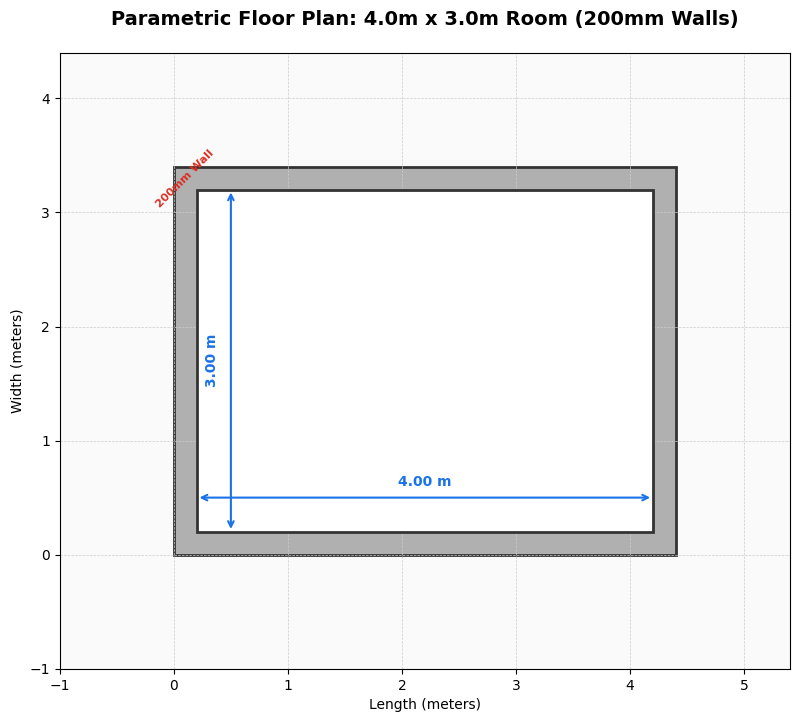

In [ ]:
import matplotlib.pyplot as plt
import matplotlib.patches as patches

def generate_floor_plan(room_l, room_w, wall_t):
    """
    Generates and displays a parameterized 2D floor plan blueprint.

    :param room_l: Interior length of the room (meters)
    :param room_w: Interior width of the room (meters)
    :param wall_t: Thickness of the walls (meters)
    """
    # 1. Calculate overall outer dimensions
    outer_l = room_l + (2 * wall_t)
    outer_w = room_w + (2 * wall_t)

    # 2. Setup the plot/canvas
    fig, ax = plt.subplots(figsize=(10, 8))

    # Set background style to look slightly like a drafting sheet
    ax.set_facecolor('#fafafa')

    # 3. Draw the Outer Wall Structure (Filled with gray to represent wall mass)
    outer_wall = patches.Rectangle(
        (0, 0), outer_l, outer_w,
        linewidth=2, edgecolor='#333333', facecolor='#b0b0b0', zorder=1
    )
    ax.add_patch(outer_wall)

    # 4. Draw the Inner Room (Overlay white to "carve out" the interior space)
    inner_room = patches.Rectangle(
        (wall_t, wall_t), room_l, room_w,
        linewidth=2, edgecolor='#333333', facecolor='white', zorder=2
    )
    ax.add_patch(inner_room)

    # 5. Blueprint Annotations & Dimensions
    # Interior Length Dimension Line (Bottom)
    dim_y_offset = wall_t + 0.3
    ax.annotate('', xy=(wall_t, dim_y_offset), xytext=(wall_t + room_l, dim_y_offset),
                arrowprops=dict(arrowstyle='<->', color='#1a73e8', linewidth=1.5))
    ax.text(wall_t + (room_l / 2), dim_y_offset + 0.1, f'{room_l:.2f} m',
            color='#1a73e8', ha='center', fontsize=10, fontweight='bold')

    # Interior Width Dimension Line (Left)
    dim_x_offset = wall_t + 0.3
    ax.annotate('', xy=(dim_x_offset, wall_t), xytext=(dim_x_offset, wall_t + room_w),
                arrowprops=dict(arrowstyle='<->', color='#1a73e8', linewidth=1.5))
    ax.text(dim_x_offset - 0.1, wall_t + (room_w / 2), f'{room_w:.2f} m',
            color='#1a73e8', va='center', ha='right', rotation=90, fontsize=10, fontweight='bold')

    # Wall Thickness Label (Top Left Corner)
    ax.text(wall_t / 2, outer_w - (wall_t / 2), f'{int(wall_t * 1000)}mm Wall',
            color='#d93025', fontsize=8, ha='center', va='center', rotation=45, fontweight='bold')

    # 6. Formatting grid, limits, and scale
    # Add padding around the house layout for a clean look
    padding = 1.0
    ax.set_xlim(-padding, outer_l + padding)
    ax.set_ylim(-padding, outer_w + padding)

    # CRITICAL: Keep the aspect ratio equal so 1m vertically equals 1m horizontally
    ax.set_aspect('equal')

    # Gridlines for engineering context
    ax.grid(True, which='both', linestyle='--', linewidth=0.5, color='#cccccc')

    # Labels & Title
    ax.set_title(f"Parametric Floor Plan: {room_l}m x {room_w}m Room ({int(wall_t*1000)}mm Walls)",
                 fontsize=14, fontweight='bold', pad=20)
    ax.set_xlabel("Length (meters)", fontsize=10)
    ax.set_ylabel("Width (meters)", fontsize=10)

    # Display the final blueprint
    plt.show()

# --- CONFIGURATION (Change these to test parameterization) ---
ROOM_LENGTH = 4.0      # meters
ROOM_WIDTH = 3.0       # meters
WALL_THICKNESS = 0.2   # 200mm in meters

# Run the generator
generate_floor_plan(ROOM_LENGTH, ROOM_WIDTH, WALL_THICKNESS)

# 2 Room version Long configuration

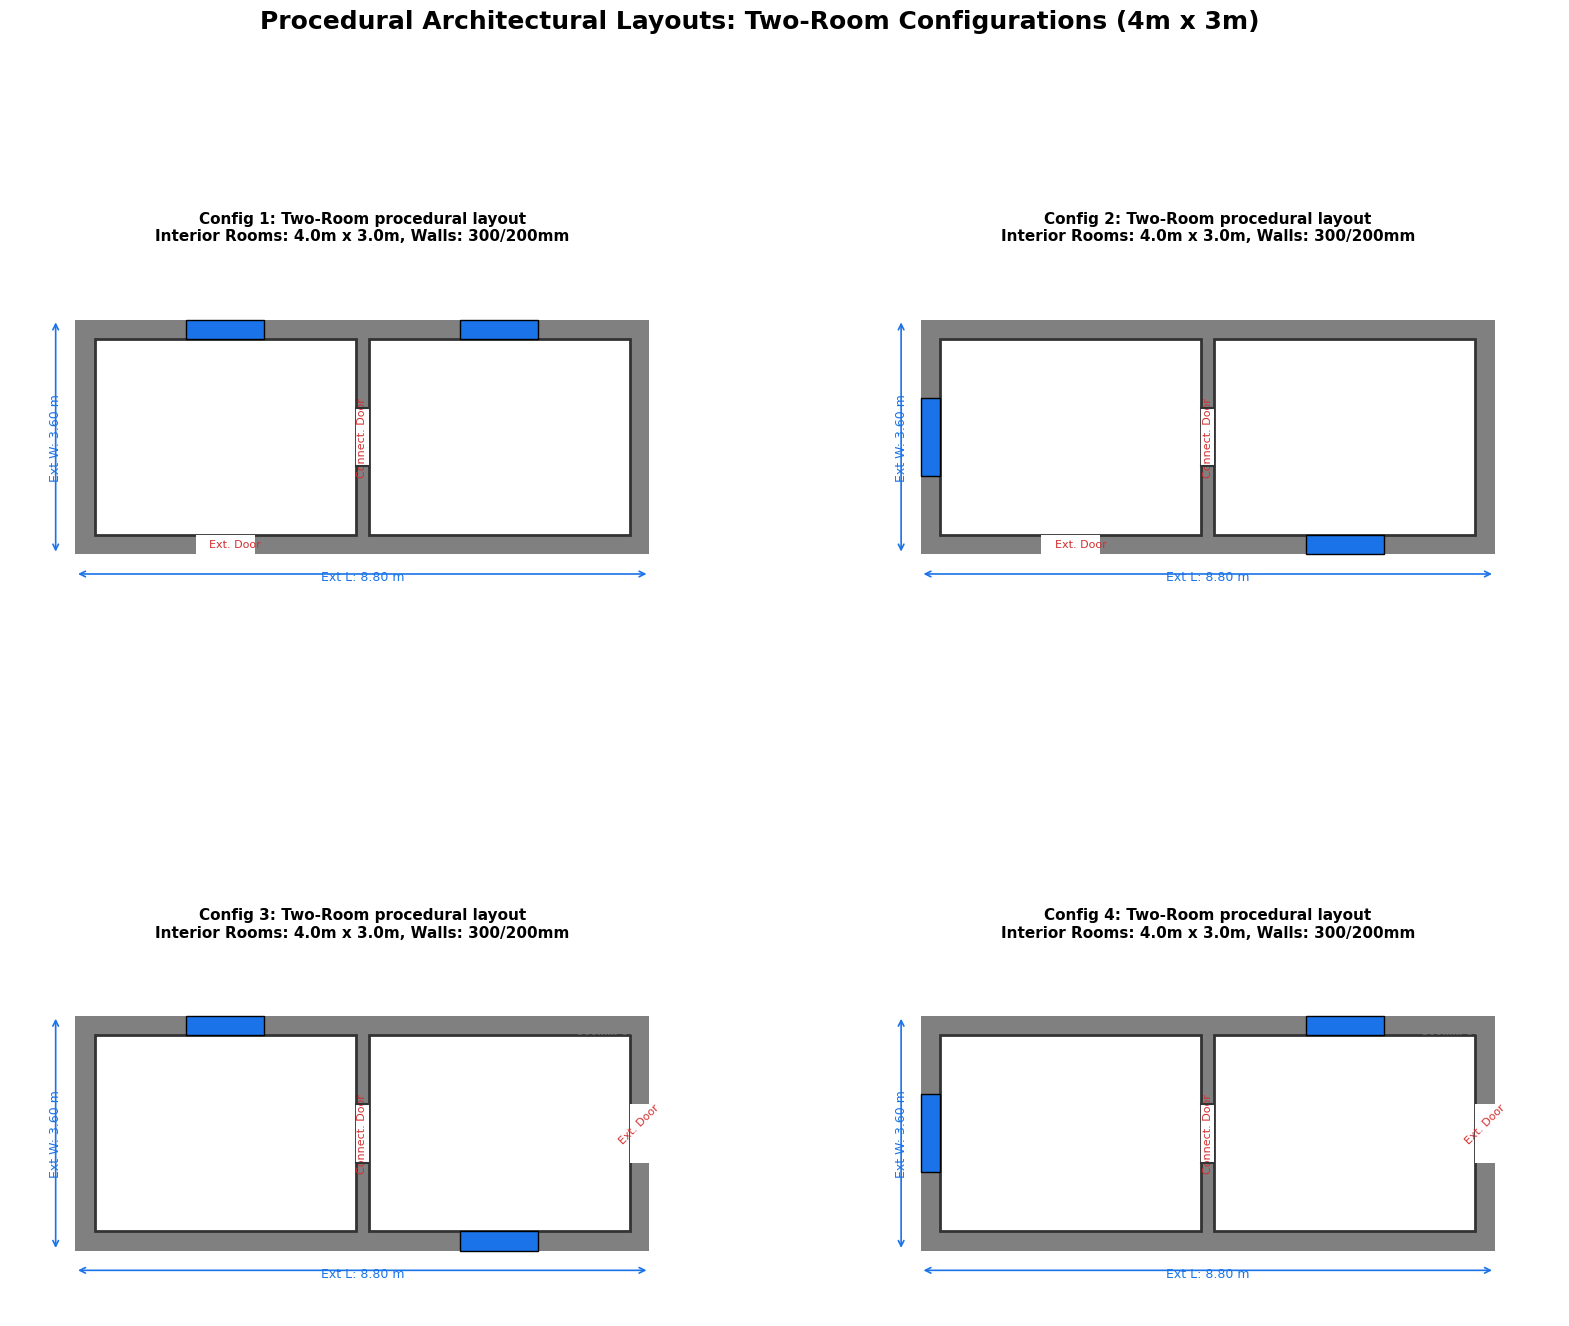

In [ ]:
import matplotlib.pyplot as plt
import matplotlib.patches as patches
import matplotlib.gridspec as gridspec

# --- PARAMETERS ---
# Interior dimensions of rooms (meters)
ROOM_L = 4.0
ROOM_W = 3.0
# Wall thicknesses (meters)
OUTER_WALL_T = 0.3  # 300mm
INNER_WALL_T = 0.2  # 200mm
# Component dimensions
DOOR_WIDTH = 0.9    # Standard 900mm door
WINDOW_WIDTH = 1.2  # Standard window size

# Base colors for the blueprint style
COLOR_WALL_SOLID = '#808080'  # Gray wall mass
COLOR_FLOOR = '#ffffff'      # White interior
COLOR_WINDOW = '#1a73e8'     # Blue for glass
COLOR_ANNOTATION = '#d32f2f' # Red for labels and dimensions
COLOR_GRID = '#cccccc'       # Light gray for grid

class HouseLayout:
    """
    Manages the geometry and drawing of the two-room house layout.
    Assuming rooms are aligned side-by-side (along the 4m side).
    """
    def __init__(self, room_l, room_w, ow_t, iw_t):
        self.room_l = room_l
        self.room_w = room_w
        self.ow_t = ow_t
        self.iw_t = iw_t

        # 1. Calculate overall structure dimensions
        # Total interior length: L_A + InnerWall + L_B
        self.total_inner_l = (2 * room_l) + iw_t
        self.total_outer_l = self.total_inner_l + (2 * ow_t)

        # Total interior width: Max(W_A, W_B) = W
        self.total_outer_w = room_w + (2 * ow_t)

        # 2. Geometric Verification of boundary boxes
        # We start the outer bottom-left at (0, 0) for calculation simplicity
        self.footprint = (0, 0, self.total_outer_l, self.total_outer_w)

        # Inner Room A starts at (OuterWall, OuterWall)
        self.room_a_box = (
            ow_t, ow_t,
            ow_t + room_l, ow_t + room_w
        )

        # Inner Room B starts after Room A and InnerWall
        self.room_b_box = (
            ow_t + room_l + iw_t, ow_t,
            ow_t + room_l + iw_t + room_l, ow_t + room_w
        )

    def draw_base_structure(self, ax):
        """Draws the solid wall mass and overlays the two white room spaces."""
        # 1. Solid Outer Wall Block (the mass)
        outer_block = patches.Rectangle(
            (0, 0), self.total_outer_l, self.total_outer_w,
            linewidth=0, facecolor=COLOR_WALL_SOLID, zorder=1
        )
        ax.add_patch(outer_block)

        # 2. "Carve out" Room A
        ra_x, ra_y, ra_xw, ra_yw = self.room_a_box
        room_a = patches.Rectangle(
            (ra_x, ra_y), self.room_l, self.room_w,
            linewidth=2, edgecolor='#333333', facecolor=COLOR_FLOOR, zorder=2
        )
        ax.add_patch(room_a)

        # 3. "Carve out" Room B
        rb_x, rb_y, rb_xw, rb_yw = self.room_b_box
        room_b = patches.Rectangle(
            (rb_x, rb_y), self.room_l, self.room_w,
            linewidth=2, edgecolor='#333333', facecolor=COLOR_FLOOR, zorder=2
        )
        ax.add_patch(room_b)

        # The space between Room A (ends at ra_xw) and Room B (starts at rb_x)
        # is the 200mm inner wall. This geometry is verified.

    def add_exterior_door(self, ax, room_label, wall_side):
        """
        Overlays a white rectangle on an outer wall to create a door 'opening'.
        """
        depth = self.ow_t
        width = DOOR_WIDTH

        # Define potential placement centers (centered within wall segment)
        # Centers are calculated by defining [Room Start, Room End] / 2
        # then shifting into the wall mass.
        centers = {
            'A': {
                'bottom': ((self.ow_t + self.room_l/2), 0),
                'top': ((self.ow_t + self.room_l/2), self.total_outer_w - depth),
                'left': (0, (self.ow_t + self.room_w/2))
            },
            'B': {
                'bottom': ((self.ow_t + self.room_l + self.iw_t + self.room_l/2), 0),
                'top': ((self.ow_t + self.room_l + self.iw_t + self.room_l/2), self.total_outer_w - depth),
                'right': (self.total_outer_l - depth, (self.ow_t + self.room_w/2))
            }
        }

        try:
            cx, cy = centers[room_label][wall_side]
        except KeyError:
            raise ValueError(f"Invalid wall_side/room_label combo: {room_label} on {wall_side}")

        # Draw the opening (white box to 'erase' the gray wall segment)
        if wall_side in ['bottom', 'top']:
            door = patches.Rectangle((cx - width/2, cy), width, depth,
                                     linewidth=0, facecolor=COLOR_FLOOR, zorder=3)
        else: # left, right are vertical openings
            door = patches.Rectangle((cx, cy - width/2), depth, width,
                                     linewidth=0, facecolor=COLOR_FLOOR, zorder=3)
        ax.add_patch(door)

        # Label the exterior door
        lx = cx + depth/2 if wall_side in ['bottom', 'top'] else cx + depth/2
        ly = cy + depth/2 if wall_side in ['bottom', 'top'] else cy + depth/2
        ax.text(lx, ly, 'Ext. Door', color=COLOR_ANNOTATION, fontsize=8,
                ha='center', va='center', rotation=45 if wall_side in ['left', 'right'] else 0)

    def add_exterior_window(self, ax, room_label, wall_side):
        """
        Draws a blue rectangle on an outer wall to represent a window.
        """
        depth = self.ow_t
        width = WINDOW_WIDTH

        # Define potential placement centers (must be on an outer wall)
        centers = {
            'A': {
                'top': ((self.ow_t + self.room_l/2), self.total_outer_w - depth),
                'left': (0, (self.ow_t + self.room_w/2))
            },
            'B': {
                'top': ((self.ow_t + self.room_l + self.iw_t + self.room_l/2), self.total_outer_w - depth),
                'bottom': ((self.ow_t + self.room_l + self.iw_t + self.room_l/2), 0),
                'right': (self.total_outer_l - depth, (self.ow_t + self.room_w/2))
            }
        }

        try:
            cx, cy = centers[room_label][wall_side]
        except KeyError:
            raise ValueError(f"Invalid wall_side/room_label combo: {room_label} on {wall_side}")

        # Draw the blue 'glass' rectangle
        if wall_side in ['bottom', 'top']:
            win = patches.Rectangle((cx - width/2, cy), width, depth,
                                    linewidth=1, edgecolor='#000000', facecolor=COLOR_WINDOW, zorder=3)
        else:
            win = patches.Rectangle((cx, cy - width/2), depth, width,
                                    linewidth=1, edgecolor='#000000', facecolor=COLOR_WINDOW, zorder=3)
        ax.add_patch(win)

    def add_connecting_door(self, ax):
        """
        Handles the complex geometry of a door through the INNER wall.
        """
        # The inner wall spans x in [ (OW_T + L_A), (OW_T + L_A + IW_T) ]
        # We will place the door center at (TotalInnerL/2 + OW_T, OuterW/2)
        inner_wall_center_x = (self.room_l + (self.iw_t / 2)) + self.ow_t
        inner_wall_center_y = self.total_outer_w / 2

        width = self.iw_t
        height = DOOR_WIDTH

        # 1. Overlay a White Rectangle on the inner wall gap (shows the opening)
        opening = patches.Rectangle(
            (self.ow_t + self.room_l, inner_wall_center_y - height/2),
            width, height,
            linewidth=0, facecolor=COLOR_FLOOR, zorder=3
        )
        ax.add_patch(opening)

        # 2. Draw Frame Lines and Label
        # Horizontal lines of the opening
        top_y = inner_wall_center_y + height/2
        bot_y = inner_wall_center_y - height/2
        x_start = self.ow_t + self.room_l
        x_end = x_start + width
        ax.plot([x_start, x_end], [top_y, top_y], color='#333333', linewidth=1.5, zorder=4)
        ax.plot([x_start, x_end], [bot_y, bot_y], color='#333333', linewidth=1.5, zorder=4)

        ax.text(inner_wall_center_x, inner_wall_center_y, 'Connect. Door',
                color=COLOR_ANNOTATION, fontsize=8, ha='center', va='center', rotation=90)


    def annotate_and_format(self, ax, config_num):
        """Adds dimensions and config titles."""
        # Main Title
        ax.set_title(f"Config {config_num}: Two-Room procedural layout\nInterior Rooms: {self.room_l}m x {self.room_w}m, Walls: {int(self.ow_t*1000)}/{int(self.iw_t*1000)}mm",
                     fontsize=11, fontweight='bold', pad=10)

        # 1. Exterior Dimensions (Overall structure size)
        # Bottom Length
        ax.annotate('', xy=(0, -0.3), xytext=(self.total_outer_l, -0.3),
                    arrowprops=dict(arrowstyle='<->', color='#1a73e8', linewidth=1.2))
        ax.text(self.total_outer_l/2, -0.4, f'Ext L: {self.total_outer_l:.2f} m', color='#1a73e8', ha='center', fontsize=9)

        # Left Width
        ax.annotate('', xy=(-0.3, 0), xytext=(-0.3, self.total_outer_w),
                    arrowprops=dict(arrowstyle='<->', color='#1a73e8', linewidth=1.2))
        ax.text(-0.4, self.total_outer_w/2, f'Ext W: {self.total_outer_w:.2f} m', color='#1a73e8', va='center', rotation=90, fontsize=9)

        # 2. Key Parameter Labels
        ax.text(self.footprint[2]-0.15, self.footprint[3]-0.15, f'{int(self.ow_t*1000)}mm OW',
                color=COLOR_WALL_SOLID, fontsize=7, ha='right', va='top', fontweight='bold', alpha=0.6)

        # ax.text(self.total_outer_l/2, self.total_outer_w/2, f'{int(self.iw_t*1000)}mm IW',
        #         color=COLOR_ANNOTATION, fontsize=7, ha='center', va='center', rotation=90, fontweight='bold', alpha=0.8)

        # 3. Canvas Formatting
        padding = 1.0
        ax.set_xlim(-padding, self.total_outer_l + padding)
        ax.set_ylim(-padding, self.total_outer_w + padding)
        ax.set_aspect('equal')
        ax.grid(True, which='both', linestyle='--', linewidth=0.5, color=COLOR_GRID)
        ax.set_axis_off() # Blueprint style, minimal axes

# --- CONFIGURATION DEFINITIONS ---
# Define 4 unique configurations. Each entry is: (Config Num, Ext Door Room/Side, Win A Side, Win B Side)
CONFIG_SET = [
    (1, ('A', 'bottom'), ('A', 'top'), ('B', 'top')),    # Core config
    (2, ('A', 'bottom'), ('A', 'left'), ('B', 'bottom')), # Split windows
    (3, ('B', 'right'),  ('A', 'top'), ('B', 'bottom')), # Door in B, opposing windows
    (4, ('B', 'right'),  ('A', 'left'), ('B', 'top'))     # Minimal outer profile
]

# --- SLIDE GENERATION ---
fig = plt.figure(figsize=(20, 16)) # Large canvas for the slide
gs = gridspec.GridSpec(2, 2, figure=fig, wspace=0.2, hspace=0.3)

# Step-by-step verification: The HouseLayout initialization calculates the geometry
# from base parameters and verifies boxes before any drawing occurs.
layout = HouseLayout(ROOM_L, ROOM_W, OUTER_WALL_T, INNER_WALL_T)

for i, config_data in enumerate(CONFIG_SET):
    num, ed_loc, wa_loc, wb_loc = config_data
    ax = fig.add_subplot(gs[i])

    # 1. Start the established method: Hollow Structure
    layout.draw_base_structure(ax)

    # 2. Add connecting door (Parameterized by geometry)
    layout.add_connecting_door(ax)

    # 3. Add dynamic exterior components (Parameterized by locations)
    layout.add_exterior_door(ax, ed_loc[0], ed_loc[1])
    layout.add_exterior_window(ax, wa_loc[0], wa_loc[1])
    layout.add_exterior_window(ax, wb_loc[0], wb_loc[1])

    # 4. Add Blueprint annotations and verify scale
    layout.annotate_and_format(ax, num)

fig.suptitle("Procedural Architectural Layouts: Two-Room Configurations (4m x 3m)", fontsize=18, fontweight='bold')
plt.show()

# 2 Rooms L-configuration

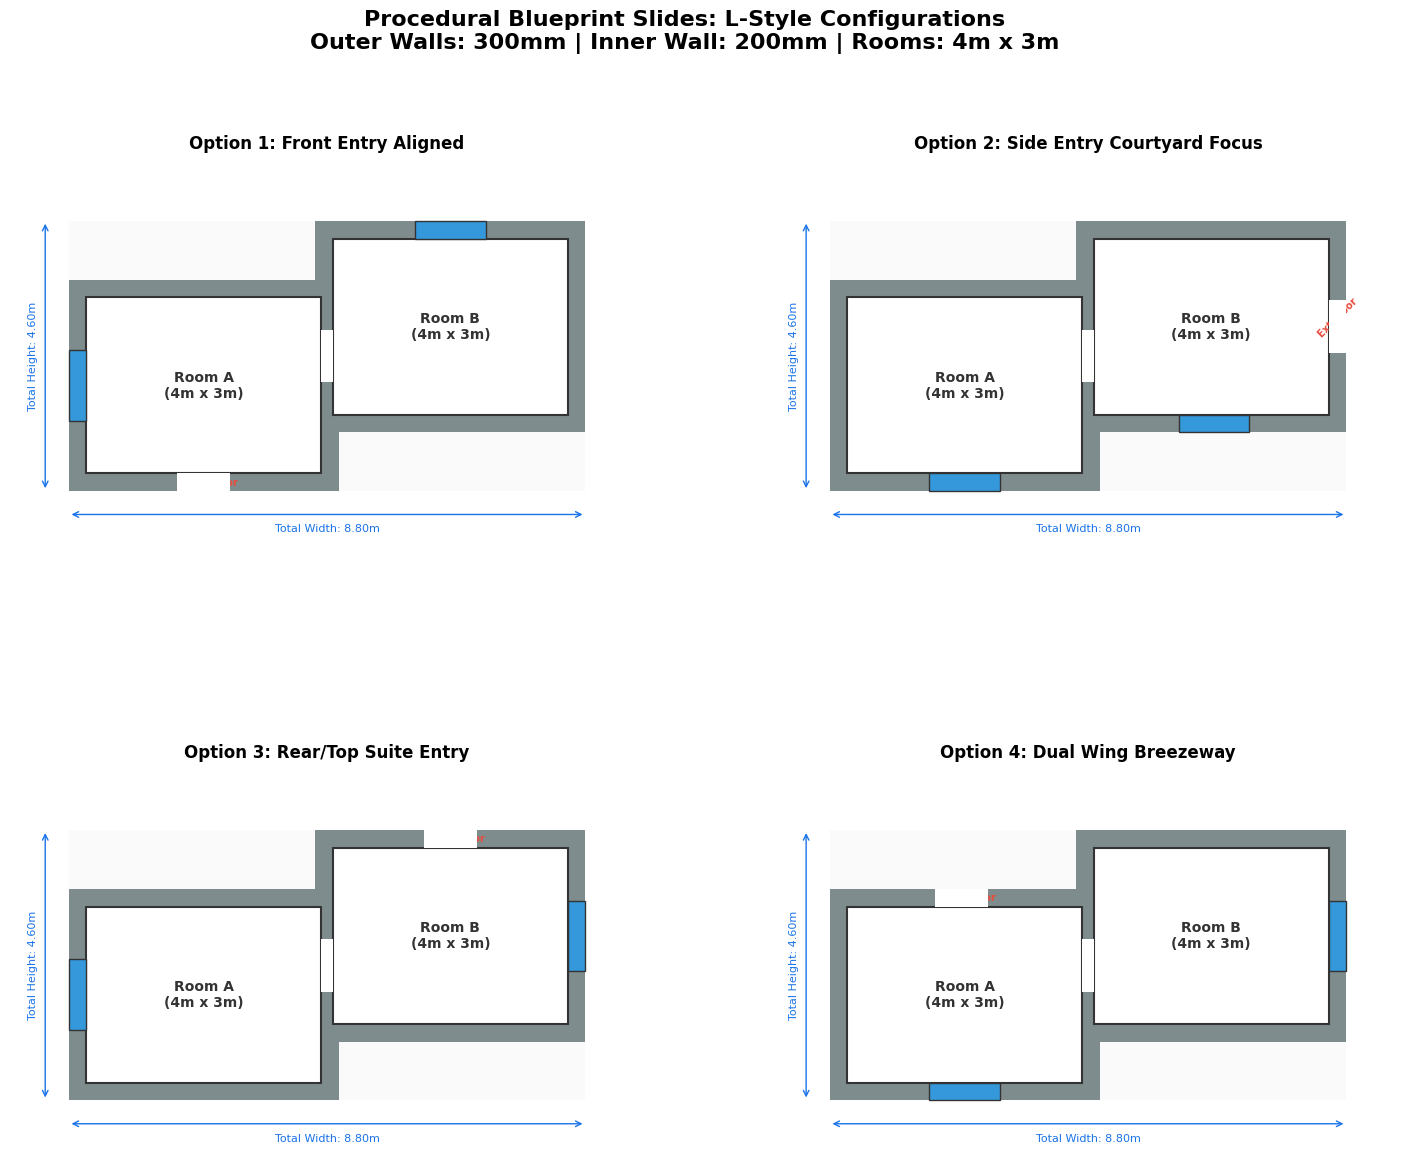

In [ ]:
import matplotlib.pyplot as plt
import matplotlib.patches as patches
import matplotlib.gridspec as gridspec

# --- PARAMETERS ---
ROOM_L = 4.0        # 4 meters
ROOM_W = 3.0        # 3 meters
OUTER_WALL_T = 0.3  # 300mm
INNER_WALL_T = 0.2  # 200mm
DOOR_WIDTH = 0.9    # 900mm
WINDOW_WIDTH = 1.2  # 1200mm
Y_OFFSET = 1.0      # Vertical shift of Room B to create the L-shape

# Styling
BG_COLOR = '#fafafa'
COLOR_WALL_SOLID = '#7f8c8d'
COLOR_FLOOR = '#ffffff'
COLOR_WINDOW = '#3498db'
COLOR_ANNOTATION = '#e74c3c'
COLOR_GRID = '#e0e0e0'

class LShapeHouseLayout:
    def __init__(self):
        # Establish precise interior coordinate boundaries
        self.ax1, self.ay1 = OUTER_WALL_T, OUTER_WALL_T
        self.ax2, self.ay2 = self.ax1 + ROOM_L, self.ay1 + ROOM_W

        self.bx1 = self.ax2 + INNER_WALL_T
        self.by1 = OUTER_WALL_T + Y_OFFSET
        self.bx2, self.by2 = self.bx1 + ROOM_L, self.by1 + ROOM_W

        # Total bounding box dimensions
        self.total_w = self.bx2 + OUTER_WALL_T
        self.total_h = self.by2 + OUTER_WALL_T

    def draw_skeleton(self, ax):
        # 1. Fill entire bounding canvas with solid wall mass
        ax.add_patch(patches.Rectangle((0, 0), self.total_w, self.total_h, facecolor=COLOR_WALL_SOLID, zorder=1))

        # 2. Carve out the two negative external spaces of the L-shape to leave 300mm outer walls
        # Top-Left outside space
        ax.add_patch(patches.Rectangle((0, self.ay2 + OUTER_WALL_T), self.bx1 - OUTER_WALL_T, self.total_h - (self.ay2 + OUTER_WALL_T), facecolor=BG_COLOR, zorder=2))
        # Bottom-Right outside space
        ax.add_patch(patches.Rectangle((self.ax2 + OUTER_WALL_T, 0), self.total_w - (self.ax2 + OUTER_WALL_T), self.by1 - OUTER_WALL_T, facecolor=BG_COLOR, zorder=2))

        # 3. Carve out interior room floors
        ax.add_patch(patches.Rectangle((self.ax1, self.ay1), ROOM_L, ROOM_W, facecolor=COLOR_FLOOR, edgecolor='#333333', linewidth=1.5, zorder=3))
        ax.add_patch(patches.Rectangle((self.bx1, self.by1), ROOM_L, ROOM_W, facecolor=COLOR_FLOOR, edgecolor='#333333', linewidth=1.5, zorder=3))

        # Label Rooms
        ax.text(self.ax1 + ROOM_L/2, self.ay1 + ROOM_W/2, "Room A\n(4m x 3m)", ha='center', va='center', fontweight='bold', color='#333333')
        ax.text(self.bx1 + ROOM_L/2, self.by1 + ROOM_W/2, "Room B\n(4m x 3m)", ha='center', va='center', fontweight='bold', color='#333333')

    def get_wall_center(self, room, side):
        """Calculates precise midpoint coordinate and orientation for components."""
        if room == 'A':
            if side == 'bottom': return (self.ax1 + ROOM_L/2, 0, 'H')
            if side == 'left':   return (0, self.ay1 + ROOM_W/2, 'V')
            if side == 'top':    return (self.ax1 + (self.bx1 - OUTER_WALL_T - self.ax1)/2, self.ay2, 'H')
        elif room == 'B':
            if side == 'top':    return (self.bx1 + ROOM_L/2, self.total_h - OUTER_WALL_T, 'H')
            if side == 'right':  return (self.total_w - OUTER_WALL_T, self.by1 + ROOM_W/2, 'V')
            if side == 'bottom': return (self.ax2 + OUTER_WALL_T + (self.bx2 - (self.ax2 + OUTER_WALL_T))/2, self.by1 - OUTER_WALL_T, 'H')
        return (0, 0, 'H')

    def add_connecting_door(self, ax):
        # Shared wall is vertical, centered in the overlapping region
        overlap_y_center = (self.by1 + self.ay2) / 2
        ax.add_patch(patches.Rectangle((self.ax2, overlap_y_center - DOOR_WIDTH/2), INNER_WALL_T, DOOR_WIDTH, facecolor=COLOR_FLOOR, zorder=4))
        ax.text(self.ax2 + INNER_WALL_T/2, overlap_y_center, "Door", color=COLOR_ANNOTATION, fontsize=7, ha='center', va='center', rotation=90, fontweight='bold')

    def add_exterior_door(self, ax, room, side):
        cx, cy, orient = self.get_wall_center(room, side)
        if orient == 'H':
            ax.add_patch(patches.Rectangle((cx - DOOR_WIDTH/2, cy), DOOR_WIDTH, OUTER_WALL_T, facecolor=COLOR_FLOOR, zorder=4))
        else:
            ax.add_patch(patches.Rectangle((cx, cy - DOOR_WIDTH/2), OUTER_WALL_T, DOOR_WIDTH, facecolor=COLOR_FLOOR, zorder=4))
        ax.text(cx + OUTER_WALL_T/2 if orient=='H' else cx + OUTER_WALL_T/2, cy + OUTER_WALL_T/2, "Ext. Door", color=COLOR_ANNOTATION, fontsize=7, ha='center', va='center', rotation=45 if orient=='V' else 0, fontweight='bold')

    def add_window(self, ax, room, side):
        cx, cy, orient = self.get_wall_center(room, side)
        if orient == 'H':
            ax.add_patch(patches.Rectangle((cx - WINDOW_WIDTH/2, cy), WINDOW_WIDTH, OUTER_WALL_T, facecolor=COLOR_WINDOW, edgecolor='#333333', zorder=4))
        else:
            ax.add_patch(patches.Rectangle((cx, cy - WINDOW_WIDTH/2), OUTER_WALL_T, WINDOW_WIDTH, facecolor=COLOR_WINDOW, edgecolor='#333333', zorder=4))

    def format_plot(self, ax, title):
        ax.set_facecolor(BG_COLOR)
        ax.set_xlim(-1, self.total_w + 1)
        ax.set_ylim(-1, self.total_h + 1)
        ax.set_aspect('equal')
        ax.grid(True, which='both', linestyle='--', linewidth=0.5, color=COLOR_GRID)
        ax.set_title(title, fontsize=12, fontweight='bold', pad=10)

        # Outer Dimensions Blueprint lines
        ax.annotate('', xy=(0, -0.4), xytext=(self.total_w, -0.4), arrowprops=dict(arrowstyle='<->', color='#1a73e8'))
        ax.text(self.total_w/2, -0.7, f"Total Width: {self.total_w:.2f}m", color='#1a73e8', ha='center', fontsize=8)
        ax.annotate('', xy=(-0.4, 0), xytext=(-0.4, self.total_h), arrowprops=dict(arrowstyle='<->', color='#1a73e8'))
        ax.text(-0.7, self.total_h/2, f"Total Height: {self.total_h:.2f}m", color='#1a73e8', va='center', rotation=90, fontsize=8)
        ax.axis('off')

# --- CONFIGURATION MATRIX ---
# Format: (Config Name, Ext Door Location, Window A Location, Window B Location)
CONFIGURATIONS = [
    ("Option 1: Front Entry Aligned", ('A', 'bottom'), ('A', 'left'), ('B', 'top')),
    ("Option 2: Side Entry Courtyard Focus", ('B', 'right'), ('A', 'bottom'), ('B', 'bottom')),
    ("Option 3: Rear/Top Suite Entry", ('B', 'top'), ('A', 'left'), ('B', 'right')),
    ("Option 4: Dual Wing Breezeway", ('A', 'top'), ('A', 'bottom'), ('B', 'right'))
]

# --- GENERATE THE SLIDE ---
fig = plt.figure(figsize=(18, 14))
gs = gridspec.GridSpec(2, 2, figure=fig, wspace=0.2, hspace=0.3)
layout_engine = LShapeHouseLayout()

for i, (title, ext_door, win_a, win_b) in enumerate(CONFIGURATIONS):
    ax = fig.add_subplot(gs[i])

    layout_engine.draw_skeleton(ax)
    layout_engine.add_connecting_door(ax)
    layout_engine.add_exterior_door(ax, ext_door[0], ext_door[1])
    layout_engine.add_window(ax, win_a[0], win_a[1])
    layout_engine.add_window(ax, win_b[0], win_b[1])

    layout_engine.format_plot(ax, title)

fig.suptitle("Procedural Blueprint Slides: L-Style Configurations\nOuter Walls: 300mm | Inner Wall: 200mm | Rooms: 4m x 3m", fontsize=16, fontweight='bold', y=0.96)
plt.show()

# 2 Bedroom House Design for a 50 ft by 100 ft plot

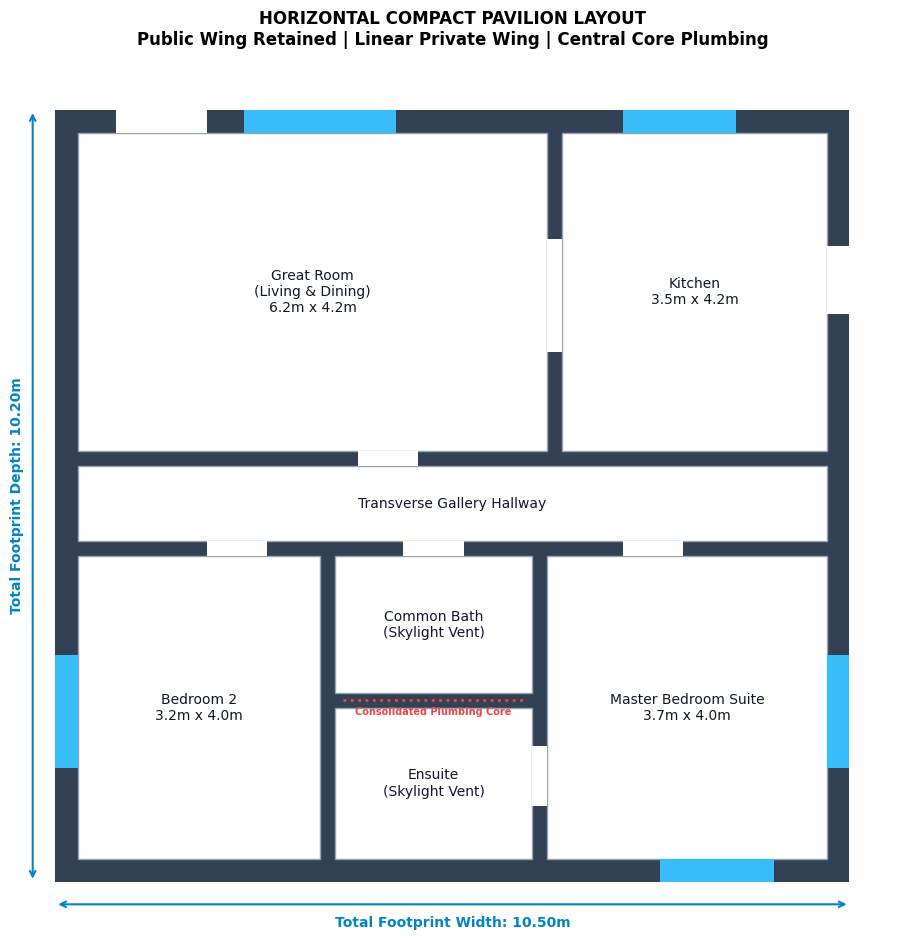

In [ ]:
import matplotlib.pyplot as plt
import matplotlib.patches as patches

def draw_horizontal_pavilion_plan():
    # New Compact Footprint: 10.5m Wide x 10.2m High
    TW, TH = 10.5, 10.2

    fig, ax = plt.subplots(figsize=(12, 11))
    ax.set_facecolor('#f8fafc')

    # 1. Base Structural Wall Mass (Outer Shell)
    ax.add_patch(patches.Rectangle((0, 0), TW, TH, facecolor='#334155'))

    # 2. Room Floor Plates (White with subtle borders)
    rooms = [
        # TOP WING (Public Zone - Kept Exactly as Requested)
        (0.3, 5.7, 6.2, 4.2, "Great Room\n(Living & Dining)\n6.2m x 4.2m"),
        (6.7, 5.7, 3.5, 4.2, "Kitchen\n3.5m x 4.2m"),

        # MID WING (Acoustic Buffer & Circulation)
        (0.3, 4.5, 9.9, 1.0, "Transverse Gallery Hallway"),

        # BOTTOM WING (Private Zone - Now Horizontally Arranged)
        (0.3, 0.3, 3.2, 4.0, "Bedroom 2\n3.2m x 4.0m"),
        (3.7, 2.5, 2.6, 1.8, "Common Bath\n(Skylight Vent)"),
        (3.7, 0.3, 2.6, 2.0, "Ensuite\n(Skylight Vent)"),
        (6.5, 0.3, 3.7, 4.0, "Master Bedroom Suite\n3.7m x 4.0m")
    ]

    for x, y, w, h, label in rooms:
        ax.add_patch(patches.Rectangle((x, y), w, h, facecolor='#ffffff', edgecolor='#94a3b8', linewidth=1))
        ax.text(x + w/2, y + h/2, label, ha='center', va='center', fontsize=10, color='#0f172a', fontweight='medium')

    # 3. Architectural Voids (Doors)
    doors = [
        # Exterior Doors
        (0.8, 9.9, 1.2, 0.3),   # Main Front Entry into Great Room
        (10.2, 7.5, 0.3, 0.9),  # Kitchen Side Exit

        # Interior Flow
        (6.5, 7.0, 0.2, 1.5),   # Archway: Living to Kitchen
        (4.0, 5.5, 0.8, 0.2),   # Door: Living to Transverse Hallway

        # Private Doors opening off the Transverse Hallway
        (2.0, 4.3, 0.8, 0.2),   # Door: Hallway to Bedroom 2
        (4.6, 4.3, 0.8, 0.2),   # Door: Hallway to Common Bath
        (7.5, 4.3, 0.8, 0.2),   # Door: Hallway to Master Suite

        # Internal Suite Door
        (6.3, 1.0, 0.2, 0.8)    # Door: Master Bedroom to Ensuite
    ]
    for x, y, w, h in doors:
        ax.add_patch(patches.Rectangle((x, y), w, h, facecolor='#ffffff'))

    # 4. Glazing & Windows (Light Blue Vectors)
    windows = [
        (2.5, 9.9, 2.0, 0.3),   # Great Room North Window
        (7.5, 9.9, 1.5, 0.3),   # Kitchen North Window
        (0, 1.5, 0.3, 1.5),     # Bedroom 2 West Window
        (8.0, 0, 1.5, 0.3),     # Master South Window
        (10.2, 1.5, 0.3, 1.5)   # Master East Window
    ]
    for x, y, w, h in windows:
        ax.add_patch(patches.Rectangle((x, y), w, h, facecolor='#38bdf8'))

    # Engineering Wet Wall Indicator
    ax.plot([3.8, 6.2], [2.4, 2.4], color='#ef4444', linestyle=':', linewidth=2)
    ax.text(5.0, 2.25, "Consolidated Plumbing Core", color='#ef4444', fontsize=7, ha='center', va='center', fontweight='bold')

    # Global Formatting & Dimension Lines
    ax.set_xlim(-0.5, TW + 0.5)
    ax.set_ylim(-0.5, TH + 0.5)
    ax.set_aspect('equal')
    ax.axis('off')

    # Annotations
    ax.annotate('', xy=(0, -0.3), xytext=(TW, -0.3), arrowprops=dict(arrowstyle='<->', color='#0284c7', linewidth=1.5))
    ax.text(TW/2, -0.6, f"Total Footprint Width: {TW:.2f}m", color='#0284c7', ha='center', fontsize=10, fontweight='bold')
    ax.annotate('', xy=(-0.3, 0), xytext=(-0.3, TH), arrowprops=dict(arrowstyle='<->', color='#0284c7', linewidth=1.5))
    ax.text(-0.6, TH/2, f"Total Footprint Depth: {TH:.2f}m", color='#0284c7', va='center', rotation=90, fontsize=10, fontweight='bold')

    ax.set_title("HORIZONTAL COMPACT PAVILION LAYOUT\nPublic Wing Retained | Linear Private Wing | Central Core Plumbing", pad=20, fontsize=12, fontweight='bold')

    plt.show()

draw_horizontal_pavilion_plan()

# 2 Bedroom House Design for a 50 ft by 100 ft plot of Land - Line by Line construction

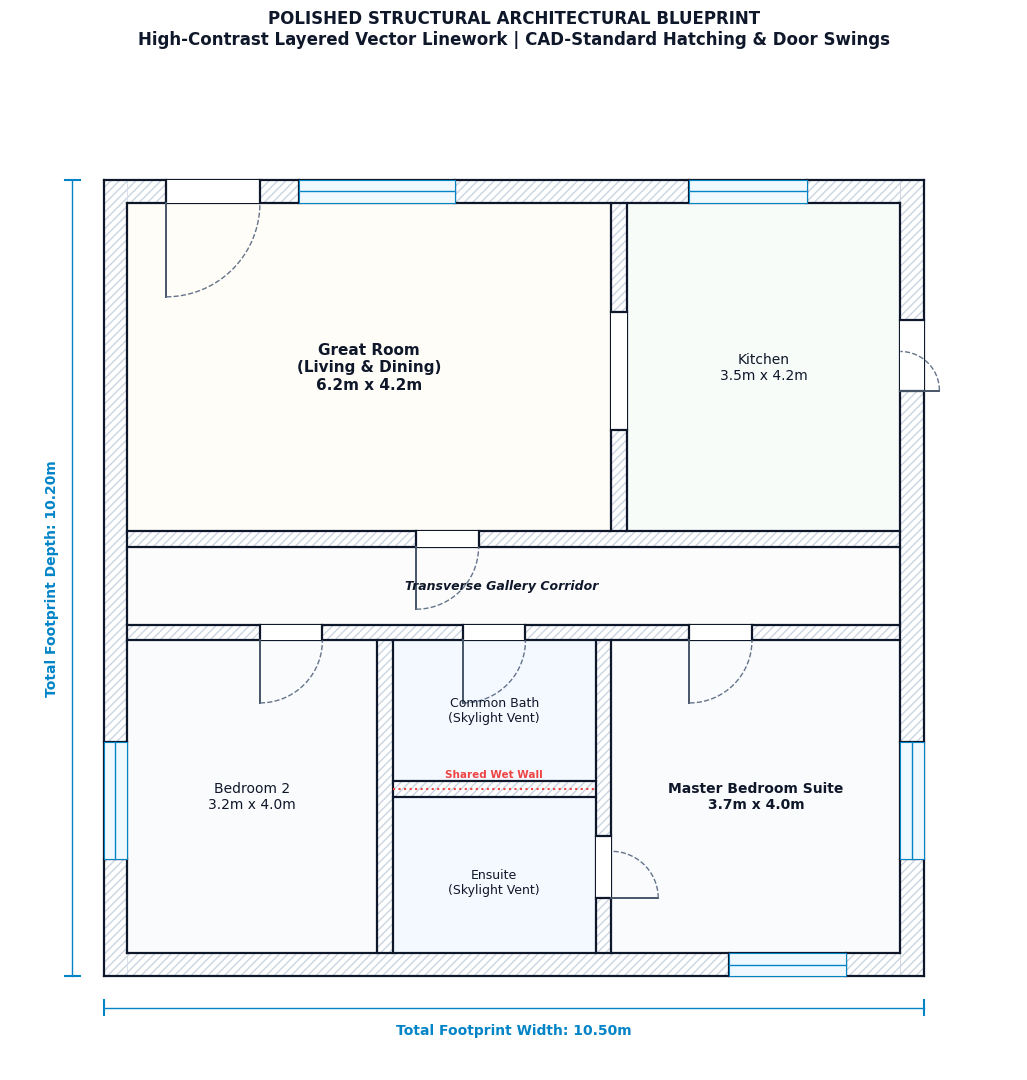

In [ ]:
import matplotlib.pyplot as plt
import matplotlib.patches as patches
import numpy as np

def draw_polished_architectural_plan():
    # Final Footprint Coordinates
    TW, TH = 10.5, 10.2

    fig, ax = plt.subplots(figsize=(13, 13))
    ax.set_facecolor('#ffffff')

    # Parametric Architectural Door Swing Helper (Guarantees perfect circular arcs)
    def draw_door_swing(cx, cy, r, start_deg, end_deg):
        theta = np.linspace(np.radians(start_deg), np.radians(end_deg), 30)
        xs = cx + r * np.cos(theta)
        ys = cy + r * np.sin(theta)
        ax.plot(xs, ys, color='#64748b', linestyle='--', linewidth=1.0, zorder=6)

    # ==========================================
    # LAYER 1: REGIONAL AMBIENT SHADING
    # ==========================================
    room_zones = [
        ((0.3, 5.7), 6.2, 4.2, '#fffdf5'), # Great Room (Warm Ivory)
        ((6.7, 5.7), 3.5, 4.2, '#f4fbf7'), # Kitchen (Mint Fresh)
        ((0.3, 0.3), 3.2, 4.0, '#f8fafc'), # Bed 2 (Crisp Slate-White)
        ((6.5, 0.3), 3.7, 4.0, '#f8fafc'), # Master
        ((3.7, 0.3), 2.6, 4.0, '#f0f7ff'), # Shared Plumbing Core (Water Blue)
        ((0.3, 4.5), 9.9, 1.0, '#fcfcfc')  # Central Gallery Walkway
    ]
    for (x, y), w, h, c in room_zones:
        ax.add_patch(patches.Rectangle((x, y), w, h, facecolor=c, edgecolor='none', alpha=0.7, zorder=1))

    # ==========================================
    # LAYER 2: WALL CAVITY STRUCTURAL HATCHING
    # ==========================================
    # White background blocks out room bleed; fine-line slate hatches add professional texture.
    wall_rects = [
        ((0, 0), 0.3, 10.2), ((10.2, 0), 0.3, 10.2), ((0.3, 0), 9.9, 0.3), ((0.3, 9.9), 9.9, 0.3),
        ((0.3, 4.3), 9.9, 0.2), ((0.3, 5.5), 9.9, 0.2), ((3.7, 2.3), 2.6, 0.2),
        ((3.5, 0.3), 0.2, 4.0), ((6.3, 0.3), 0.2, 4.0), ((6.5, 5.7), 0.2, 4.2)
    ]
    for (x, y), w, h in wall_rects:
        ax.add_patch(patches.Rectangle((x, y), w, h, facecolor='#ffffff', edgecolor='none', zorder=2))
        ax.add_patch(patches.Rectangle((x, y), w, h, facecolor='none', edgecolor='#cbd5e1', hatch='////', linewidth=0.5, zorder=2))

    # ==========================================
    # LAYER 3: CORE BLACK DRAFTING LINEWORK
    # ==========================================
    structural_lines = [
        ([0, TW], [0, 0]), ([0.3, TW-0.3], [0.3, 0.3]),
        ([0.3, TW-0.3], [4.3, 4.3]), ([0.3, TW-0.3], [4.5, 4.5]),
        ([0.3, TW-0.3], [5.5, 5.5]), ([0.3, TW-0.3], [5.7, 5.7]),
        ([0.3, TW-0.3], [9.9, 9.9]), ([0, TW], [10.2, 10.2]),
        ([3.7, 6.3], [2.3, 2.3]), ([3.7, 6.3], [2.5, 2.5]),
        ([0, 0], [0, TH]), ([0.3, 0.3], [0.3, TH-0.3]),
        ([3.5, 3.5], [0.3, 4.3]), ([3.7, 3.7], [0.3, 4.3]),
        ([6.3, 6.3], [0.3, 4.3]), ([6.5, 6.5], [0.3, 4.3]),
        ([6.5, 6.5], [5.7, 9.9]), ([6.7, 6.7], [5.7, 9.9]),
        ([10.2, 10.2], [0.3, TH-0.3]), ([10.5, 10.5], [0, TH])
    ]
    for x_coords, y_coords in structural_lines:
        ax.plot(x_coords, y_coords, color='#0f172a', linewidth=1.6, zorder=3)

    # ==========================================
    # LAYER 4 & 5: VOID MASKS & STRUCTURAL END-CAPS
    # ==========================================
    void_masks = [
        (0.8, 9.9, 1.2, 0.3), (10.2, 7.5, 0.3, 0.9), (6.5, 7.0, 0.2, 1.5),
        (4.0, 5.5, 0.8, 0.2), (2.0, 4.3, 0.8, 0.2), (4.6, 4.3, 0.8, 0.2),
        (7.5, 4.3, 0.8, 0.2), (6.3, 1.0, 0.2, 0.8),
        (2.5, 9.9, 2.0, 0.3), (7.5, 9.9, 1.5, 0.3), # North Windows
        (0, 1.5, 0.3, 1.5), (10.2, 1.5, 0.3, 1.5),  # West & East Windows
        (8.0, 0, 1.5, 0.3)                          # South Window
    ]
    for x, y, w, h in void_masks:
        ax.add_patch(patches.Rectangle((x, y), w, h, facecolor='#ffffff', edgecolor='none', zorder=4))
        if w > h: # Horizontal wall cuts
            ax.plot([x, x], [y, y+h], color='#0f172a', linewidth=1.6, zorder=5)
            ax.plot([x+w, x+w], [y, y+h], color='#0f172a', linewidth=1.6, zorder=5)
        else: # Vertical wall cuts
            ax.plot([x, x+w], [y, y], color='#0f172a', linewidth=1.6, zorder=5)
            ax.plot([x, x+w], [y+h, y+h], color='#0f172a', linewidth=1.6, zorder=5)

    # ==========================================
    # LAYER 6: DETAILED ARCHITECTURAL COMPONENTS
    # ==========================================
    # Clean Door Leafs & Parametric Clearance Arcs
    # Format: Leaf Line (x, y), Swing Center (x, y), Radius, Start Ang, End Ang
    doors = [
        (([0.8, 0.8], [9.9, 8.7]), 0.8, 9.9, 1.2, 270, 360),     # Entry
        (([10.2, 10.7], [7.5, 7.5]), 10.2, 7.5, 0.5, 0, 90),     # Kitchen
        (([4.0, 4.0], [5.5, 4.7]), 4.0, 5.5, 0.8, 270, 360),     # Hallway
        (([2.0, 2.0], [4.3, 3.5]), 2.0, 4.3, 0.8, 270, 360),     # Bed 2
        (([4.6, 4.6], [4.3, 3.5]), 4.6, 4.3, 0.8, 270, 360),     # Bath
        (([7.5, 7.5], [4.3, 3.5]), 7.5, 4.3, 0.8, 270, 360),     # Master
        (([6.5, 7.1], [1.0, 1.0]), 6.5, 1.0, 0.6, 0, 90)         # Ensuite
    ]
    for (xl, yl), cx, cy, r, s_deg, e_deg in doors:
        ax.plot(xl, yl, color='#475569', linewidth=1.4, zorder=6)
        draw_door_swing(cx, cy, r, s_deg, e_deg)

    # High-Fidelity Window Mullion & Frame Assemblies
    windows = [
        (2.5, 9.9, 2.0, 0.3, 'H'), (7.5, 9.9, 1.5, 0.3, 'H'), # North
        (0, 1.5, 0.3, 1.5, 'V'), (10.2, 1.5, 0.3, 1.5, 'V'),  # West/East
        (8.0, 0, 1.5, 0.3, 'H')                               # South
    ]
    for x, y, w, h, orient in windows:
        ax.add_patch(patches.Rectangle((x, y), w, h, facecolor='#f0f9ff', edgecolor='#0284c7', linewidth=0.8, zorder=6))
        if orient == 'H':
            ax.plot([x, x+w], [y + h/2, y + h/2], color='#0284c7', linewidth=1.0, zorder=6)
        else:
            ax.plot([x + w/2, x + w/2], [y, y+h], color='#0284c7', linewidth=1.0, zorder=6)

    # ==========================================
    # LAYER 7: TYPOGRAPHY, CORE ANNOTATIONS & DIMENSIONS
    # ==========================================
    annotations = [
        (3.4, 7.8, "Great Room\n(Living & Dining)\n6.2m x 4.2m", 11, 'center', 'bold', 'normal'),
        (8.45, 7.8, "Kitchen\n3.5m x 4.2m", 10, 'center', 'normal', 'normal'),
        (5.1, 5.0, "Transverse Gallery Corridor", 9, 'center', 'semibold', 'italic'),
        (1.9, 2.3, "Bedroom 2\n3.2m x 4.0m", 10, 'center', 'normal', 'normal'),
        (5.0, 3.4, "Common Bath\n(Skylight Vent)", 9, 'center', 'normal', 'normal'),
        (5.0, 1.2, "Ensuite\n(Skylight Vent)", 9, 'center', 'normal', 'normal'),
        (8.35, 2.3, "Master Bedroom Suite\n3.7m x 4.0m", 10, 'center', 'bold', 'normal')
    ]
    for x, y, txt, sz, align, weight, style in annotations:
        ax.text(x, y, txt, ha=align, va='center', fontsize=sz, color='#0f172a',
                fontweight=weight, fontstyle=style, zorder=7)

    # Precision Wet-Wall Boundary Line
    ax.plot([3.7, 6.3], [2.4, 2.4], color='#ef4444', linestyle=':', linewidth=1.5, zorder=7)
    ax.text(5.0, 2.55, "Shared Wet Wall", color='#ef4444', fontsize=7.5, ha='center', fontweight='bold', zorder=7)

    # Polished Dimension String (Bottom Width)
    ax.plot([0, TW], [-0.4, -0.4], color='#0284c7', linewidth=1.0, zorder=7)
    ax.plot([0, 0], [-0.5, -0.3], color='#0284c7', linewidth=1.5, zorder=7)
    ax.plot([TW, TW], [-0.5, -0.3], color='#0284c7', linewidth=1.5, zorder=7)
    ax.text(TW/2, -0.75, "Total Footprint Width: 10.50m", color='#0284c7', ha='center', fontsize=10, fontweight='bold')

    # Polished Dimension String (Left Depth)
    ax.plot([-0.4, -0.4], [0, TH], color='#0284c7', linewidth=1.0, zorder=7)
    ax.plot([-0.5, -0.3], [0, 0], color='#0284c7', linewidth=1.5, zorder=7)
    ax.plot([-0.5, -0.3], [TH, TH], color='#0284c7', linewidth=1.5, zorder=7)
    ax.text(-0.75, TH/2, "Total Footprint Depth: 10.20m", color='#0284c7', va='center', rotation=90, fontsize=10, fontweight='bold')

    # Coordinate Envelope & Render Controls
    ax.set_xlim(-1.2, TW + 1.2)
    ax.set_ylim(-1.2, TH + 1.2)
    ax.set_aspect('equal')
    ax.axis('off')

    ax.set_title("POLISHED STRUCTURAL ARCHITECTURAL BLUEPRINT\nHigh-Contrast Layered Vector Linework | CAD-Standard Hatching & Door Swings",
                 pad=30, fontsize=12, fontweight='bold', color='#0f172a')

    plt.show()

draw_polished_architectural_plan()

# Video Version 1

In [ ]:
"""
Author: Mugambi Ndwiga
Instagram: @craftsandengineering
Concept: Cinematic blueprint floor-plan reveal
Reference: github.com/zombimann/Mathematical-video-animations-and-visualization
"""

from pathlib import Path
import math
import shutil

import matplotlib.pyplot as plt
import matplotlib.patches as patches
import matplotlib.font_manager as fm
import matplotlib.colors as mcolors
from matplotlib.animation import FFMpegWriter
from matplotlib.patheffects import Stroke, Normal
import numpy as np
from IPython.display import Video, FileLink, display

# -----------------------------------------------------------------------------
# Palette - Updated for strict binary theming
# -----------------------------------------------------------------------------
DYED_BLUE     = "#121A24"
BLOTTING_BLUE = "#1B2634"
WHITE_INK     = "#F2F5F8"
SLATE_PENCIL  = "#8FA3B5"
ACCENT_GOLD   = "#D9B48F"
PURE_WHITE    = "#FFFFFF"

# -----------------------------------------------------------------------------
# Font fallback
# -----------------------------------------------------------------------------
preferred_fonts = [
    "C059",
    "EB Garamond",
    "Noto Serif",
    "Liberation Serif",
    "DejaVu Serif",
    "Nimbus Roman",
]
available_fonts = {f.name for f in fm.fontManager.ttflist}
FONT_MAIN = next((f for f in preferred_fonts if f in available_fonts), "DejaVu Serif")

plt.rcParams.update({
    "font.family": FONT_MAIN,
    "mathtext.fontset": "stix",
    "axes.unicode_minus": False,
})

# -----------------------------------------------------------------------------
# Video settings
# -----------------------------------------------------------------------------
FPS = 16
FRAME_WIDTH_PX = 720
FRAME_HEIGHT_PX = 1280
DPI = 100
FRAME_SIZE = (FRAME_WIDTH_PX / DPI, FRAME_HEIGHT_PX / DPI)
OUTPUT_PATH = Path("cinematic_blueprint_floorplan.mp4")

# Tight framing, no giant dead space
XMIN, XMAX = -0.08, 10.98
YMIN, YMAX = -0.42, 11.02
TW, TH = 10.5, 10.2

WATERMARK_TEXT = "© Mugambi Ndwiga / @craftsandengineering"

# -----------------------------------------------------------------------------
# Small utilities
# -----------------------------------------------------------------------------
def clamp01(v):
    return max(0.0, min(1.0, float(v)))

def lerp(a, b, t):
    return a + (b - a) * t

def ease_out_cubic(t):
    t = clamp01(t)
    return 1.0 - (1.0 - t) ** 3

def ease_in_out_cubic(t):
    t = clamp01(t)
    return 4 * t**3 if t < 0.5 else 1 - (-2 * t + 2) ** 3 / 2

def blend_color(c1, c2, t):
    a = np.array(mcolors.to_rgb(c1), dtype=float)
    b = np.array(mcolors.to_rgb(c2), dtype=float)
    return tuple(a * (1.0 - t) + b * t)

def unpack_rect(rect):
    if len(rect) == 4 and not isinstance(rect[0], tuple):
        return rect
    if len(rect) == 3 and isinstance(rect[0], tuple):
        (x, y), w, h = rect
        return x, y, w, h
    raise ValueError(f"Unsupported rect format: {rect!r}")

def rounded_box(ax, xy, w, h, fc, ec, alpha=0.55, lw=1.0, radius=0.06, z=50):
    x, y = xy
    box = patches.FancyBboxPatch(
        (x, y), w, h,
        boxstyle=patches.BoxStyle("Round", pad=radius),
        facecolor=fc, edgecolor=ec, linewidth=lw, alpha=alpha, zorder=z
    )
    ax.add_patch(box)
    return box

def draw_text(ax, x, y, txt, color, size=12, weight="normal", style="normal",
              ha="center", va="center", z=60, alpha=1.0):
    artist = ax.text(
        x, y, txt,
        fontsize=size, fontweight=weight, fontstyle=style,
        color=color, ha=ha, va=va, zorder=z, alpha=alpha
    )
    # Subtle background stroke to maintain legibility
    artist.set_path_effects([
        Stroke(linewidth=2.5, foreground=(1, 1, 1, 0.16) if color == WHITE_INK else (1, 1, 1, 0.8)),
        Normal()
    ])
    return artist

def draw_watermark(ax, ink_color, closing=False):
    if closing:
        ax.text(
            0.03, 0.03, WATERMARK_TEXT,
            transform=ax.transAxes,
            ha="left", va="bottom",
            fontsize=8.2, color=ink_color, alpha=0.60, zorder=90
        )
    else:
        ax.text(
            0.985, 0.016, WATERMARK_TEXT,
            transform=ax.transAxes,
            ha="right", va="bottom",
            fontsize=8.2, color=ink_color, alpha=0.60, zorder=90
        )

def style_mix(t_seconds, switch_time, transition=0.75):
    if t_seconds <= switch_time:
        return 0.0
    return ease_in_out_cubic((t_seconds - switch_time) / transition)

def background(ax, mix, bg_color, ink_color):
    ax.set_xlim(XMIN, XMAX)
    ax.set_ylim(YMIN, YMAX)
    ax.set_aspect("equal")
    ax.axis("off")

    ax.add_patch(
        patches.Rectangle(
            (XMIN, YMIN), XMAX - XMIN, YMAX - YMIN,
            facecolor=bg_color, edgecolor="none", zorder=0
        )
    )

    grid_alpha = 0.12
    grid_color = blend_color(ink_color, SLATE_PENCIL, 0.35)
    for x in np.arange(math.floor(XMIN), math.ceil(XMAX) + 0.001, 0.35):
        ax.plot([x, x], [YMIN, YMAX], color=grid_color, linewidth=0.45, alpha=grid_alpha, zorder=0)
    for y in np.arange(math.floor(YMIN), math.ceil(YMAX) + 0.001, 0.35):
        ax.plot([XMIN, XMAX], [y, y], color=grid_color, linewidth=0.45, alpha=grid_alpha, zorder=0)

    if mix > 0.02:
        stains = [
            (0.7, 0.8, 2.6, 1.2, 0.06),
            (8.4, 10.2, 2.0, 1.0, 0.05),
            (9.6, 2.0, 1.4, 0.9, 0.045),
            (2.4, 8.8, 1.8, 0.8, 0.04),
            (5.5, 5.0, 1.3, 0.7, 0.03),
        ]
        for x, y, w, h, a in stains:
            ax.add_patch(
                patches.Ellipse(
                    (x, y), w, h,
                    facecolor=ACCENT_GOLD,
                    edgecolor="none",
                    alpha=a * mix,
                    zorder=0
                )
            )

def draw_corner_label(ax, t_seconds, mix, title, subtitle, ink_color):
    a = ease_out_cubic(min(t_seconds / 0.7, 1.0))
    if a <= 0.01:
        return
    x, y, w, h = 0.20, 10.70, 5.20, 0.86

    fc = mcolors.to_rgba(ink_color, 0.08)
    ec = mcolors.to_rgba(ink_color, 0.88)

    rounded_box(
        ax, (x, y), w, h,
        fc=fc, ec=ec,
        alpha=0.12 + 0.18 * a,
        lw=1.0, z=58
    )
    ax.plot([x + 0.12, x + 0.12], [y + 0.10, y + h - 0.10],
            color=ACCENT_GOLD, linewidth=1.5, alpha=a, zorder=59)
    draw_text(ax, x + 0.26, y + 0.58, title, color=ink_color, size=15.0, weight="bold",
              ha="left", alpha=a, z=60)
    draw_text(ax, x + 0.26, y + 0.25, subtitle, color=SLATE_PENCIL, size=8.8, style="italic",
              ha="left", alpha=a, z=60)

def draw_pen_tip(ax, x, y, angle, size=0.13, color=WHITE_INK, alpha=0.95):
    dx = math.cos(angle)
    dy = math.sin(angle)
    nx = -dy
    ny = dx
    tip = np.array([x, y])
    back = tip - size * np.array([dx, dy])
    left = back + 0.52 * size * np.array([nx, ny])
    right = back - 0.52 * size * np.array([nx, ny])
    body = np.array([tip, left, back - 0.22 * size * np.array([dx, dy]), right])
    ax.add_patch(
        patches.Polygon(body, closed=True, facecolor=color,
                        edgecolor="none", alpha=alpha, zorder=70)
    )

def draw_partial_line(ax, p0, p1, t, color, lw=1.7, pen=True, alpha=0.98):
    x0, y0 = p0
    x1, y1 = p1
    t = ease_in_out_cubic(t)
    xt = lerp(x0, x1, t)
    yt = lerp(y0, y1, t)
    ax.plot([x0, xt], [y0, yt], color=color, linewidth=lw,
            alpha=alpha, solid_capstyle="round", zorder=30)
    if pen and t < 1.0:
        angle = math.atan2(y1 - y0, x1 - x0)
        draw_pen_tip(ax, xt, yt, angle, size=0.13, color=color, alpha=0.95)
        ax.scatter([xt], [yt], s=10, color=color, alpha=0.45, zorder=69)

def draw_partial_arc(ax, center, r, start_deg, end_deg, t,
                     color, lw=1.15, ls="--", alpha=0.92):
    cx, cy = center
    t = ease_in_out_cubic(t)
    theta = np.linspace(np.radians(start_deg), np.radians(lerp(start_deg, end_deg, t)), 32)
    xs = cx + r * np.cos(theta)
    ys = cy + r * np.sin(theta)
    ax.plot(xs, ys, color=color, linestyle=ls, linewidth=lw, alpha=alpha, zorder=36)

def draw_room_wash(ax, rect, t, mix):
    (x, y), w, h, color = rect
    t = ease_out_cubic(t)
    if mix < 0.02:
        return
    ax.add_patch(
        patches.Rectangle(
            (x, y), w * t, h,
            facecolor=color, edgecolor="none",
            alpha=(0.10 + 0.14 * t) * mix, zorder=4
        )
    )

def create_hatch_strokes(rect, strokes=4):
    x, y, w, h = unpack_rect(rect)
    segments = []
    if w >= h:
        usable = max(w - h * 1.1, 0.01)
        for i in range(strokes):
            s = (i + 1) / (strokes + 1)
            sx = x + s * usable
            sy = y
            ex = min(x + w, sx + h * 0.98)
            ey = y + h
            segments.append(((sx, sy), (ex, ey)))
    else:
        usable = max(h - w * 1.1, 0.01)
        for i in range(strokes):
            s = (i + 1) / (strokes + 1)
            sx = x
            sy = y + s * usable
            ex = x + w
            ey = min(y + h, sy + w * 0.98)
            segments.append(((sx, sy), (ex, ey)))
    return segments

def draw_hatch_stroke(ax, segment, t, mix, lw=0.62):
    draw_partial_line(ax, segment[0], segment[1], t, color=SLATE_PENCIL, lw=lw, pen=False, alpha=0.55)

def draw_door_leaf(ax, door, t, mix, ink_color):
    (xl, yl), cx, cy, r, s_deg, e_deg = door
    draw_partial_line(ax, (xl[0], yl[0]), (xl[1], yl[1]), t, color=ink_color, lw=1.35, pen=False, alpha=0.98)

def draw_door_hinge(ax, door, t, mix, ink_color):
    (_, _), cx, cy, _, _, _ = door
    t = ease_out_cubic(t)
    ax.scatter([cx], [cy], s=14 + 16 * t, color=ink_color, alpha=0.68 * t, zorder=37)

def draw_door_swing(ax, door, t, mix, ink_color):
    (_, _), cx, cy, r, s_deg, e_deg = door
    draw_partial_arc(ax, (cx, cy), r, s_deg, e_deg, t,
                     color=ink_color, lw=1.05, ls="--", alpha=0.92)

def draw_window_frame(ax, window, t, mix, ink_color):
    x, y, w, h, orient = window
    t = ease_out_cubic(t)
    if orient == "H":
        ww, hh = w * t, h
    else:
        ww, hh = w, h * t
    face = mcolors.to_rgba(ink_color, 0.18 + 0.24 * t)
    ax.add_patch(
        patches.Rectangle(
            (x, y), ww, hh,
            facecolor=face,
            edgecolor=ink_color,
            linewidth=0.95,
            alpha=0.45 + 0.45 * t,
            zorder=41
        )
    )

def draw_window_mullion(ax, window, t, mix, ink_color):
    x, y, w, h, orient = window
    t = ease_out_cubic(t)
    if orient == "H":
        ax.plot([x, x + w], [y + h / 2, y + h / 2],
                color=ink_color, linewidth=0.9, alpha=t, zorder=42)
    else:
        ax.plot([x + w / 2, x + w / 2], [y, y + h],
                color=ink_color, linewidth=0.9, alpha=t, zorder=42)

def draw_annotation(ax, ann, t, mix, ink_color):
    x, y, txt, size, align, weight, style = ann
    t = ease_out_cubic(t)
    draw_text(ax, x, y, txt, color=ink_color, size=size, weight=weight, style=style,
              ha=align, alpha=t, z=56)

def draw_dimension_base(ax, t, horizontal=True):
    t = ease_in_out_cubic(t)
    if horizontal:
        y = -0.38
        ax.plot([0, TW * t], [y, y], color=ACCENT_GOLD, linewidth=1.25, zorder=45, alpha=0.95)
    else:
        x = -0.38
        ax.plot([x, x], [0, TH * t], color=ACCENT_GOLD, linewidth=1.25, zorder=45, alpha=0.95)

def draw_dimension_ticks(ax, t, horizontal=True):
    t = ease_out_cubic(t)
    if horizontal:
        y = -0.38
        ax.plot([0, 0], [y - 0.09, y + 0.09], color=ACCENT_GOLD, linewidth=1.6, zorder=46, alpha=t)
        ax.plot([TW, TW], [y - 0.09, y + 0.09], color=ACCENT_GOLD, linewidth=1.6, zorder=46, alpha=t)
    else:
        x = -0.38
        ax.plot([x - 0.09, x + 0.09], [0, 0], color=ACCENT_GOLD, linewidth=1.6, zorder=46, alpha=t)
        ax.plot([x - 0.09, x + 0.09], [TH, TH], color=ACCENT_GOLD, linewidth=1.6, zorder=46, alpha=t)

def draw_dimension_label(ax, t, horizontal=True):
    t = ease_out_cubic(t)
    if horizontal:
        draw_text(
            ax, TW / 2, -0.73,
            "Total Footprint Width: 10.50 m",
            color=ACCENT_GOLD, size=10.4, weight="bold",
            alpha=t, z=47
        )
    else:
        draw_text(
            ax, -0.72, TH / 2,
            "Total Footprint Depth: 10.20 m",
            color=ACCENT_GOLD, size=10.4, weight="bold",
            alpha=t, z=47
        )

def draw_shared_wet_wall_label(ax, t, mix):
    t = ease_out_cubic(t)
    ax.plot([3.7, 6.3], [2.4, 2.4], color=ACCENT_GOLD, linestyle=":", linewidth=1.35, zorder=48, alpha=t)
    draw_text(ax, 5.0, 2.56, "Shared Wet Wall", color=ACCENT_GOLD, size=7.8, weight="bold", alpha=t, z=49)

def draw_title_block(ax, t, ink_color):
    t = ease_out_cubic(t)
    x, y, w, h = 8.14, 0.30, 2.68, 2.00

    fc = mcolors.to_rgba(ink_color, 0.08)
    ec = mcolors.to_rgba(ink_color, 0.88)

    rounded_box(
        ax, (x, y), w, h,
        fc=fc, ec=ec,
        alpha=0.14 + 0.20 * t, lw=1.0, z=57
    )
    ax.plot([x + 0.12, x + w - 0.12], [y + h - 0.35, y + h - 0.35],
            color=ACCENT_GOLD, linewidth=1.3, alpha=t, zorder=58)
    draw_text(ax, x + 0.14, y + 1.58, "PROJECT", color=ink_color, size=8.5, weight="bold",
              ha="left", alpha=t, z=59)
    draw_text(ax, x + 0.14, y + 1.23, "Blueprint in Motion", color=ink_color, size=12.7,
              weight="bold", ha="left", alpha=t, z=59)
    draw_text(ax, x + 0.14, y + 0.87, "Author: Mugambi Ndwiga", color=ink_color, size=9.2,
              ha="left", alpha=t, z=59)
    draw_text(ax, x + 0.14, y + 0.56, "@craftsandengineering", color=SLATE_PENCIL, size=9.2,
              ha="left", alpha=t, z=59)
    draw_text(ax, x + 0.14, y + 0.23, "Link to code is in the Description", color=SLATE_PENCIL, size=8.9,
              ha="left", style="italic", alpha=t, z=59)

def draw_closing_card(ax, t, bg_color, ink_color):
    t = ease_out_cubic(t)
    ax.add_patch(
        patches.Rectangle(
            (XMIN, YMIN), XMAX - XMIN, YMAX - YMIN,
            facecolor=bg_color, edgecolor="none", zorder=1
        )
    )
    ax.add_patch(
        patches.Rectangle((XMIN, YMIN), XMAX - XMIN, 1.15,
                          facecolor=ACCENT_GOLD, edgecolor="none",
                          alpha=0.06, zorder=2)
    )
    ax.add_patch(
        patches.Rectangle((XMIN, 10.00), XMAX - XMIN, 1.15,
                          facecolor=ink_color, edgecolor="none",
                          alpha=0.05, zorder=2)
    )

    fc = mcolors.to_rgba(ink_color, 0.09)
    ec = mcolors.to_rgba(ink_color, 0.88)

    rounded_box(
        ax, (1.08, 4.05), 8.88, 4.00,
        fc=fc, ec=ec,
        alpha=0.20 + 0.24 * t, lw=1.0, z=10
    )
    draw_text(ax, 5.52, 6.95, "Made by Mugambi Ndwiga", color=ink_color,
              size=22, weight="bold", alpha=t, z=20)
    draw_text(ax, 5.52, 6.14, "@craftsandengineering", color=ACCENT_GOLD,
              size=15, weight="bold", alpha=t, z=20)
    draw_text(ax, 5.52, 5.32, "Link to code is in the Description", color=ink_color,
              size=13.8, style="italic", alpha=t, z=20)
    draw_text(ax, 5.52, 4.62, "Architectural floor plan animation", color=SLATE_PENCIL,
              size=11.2, alpha=0.92 * t, z=20)

# -----------------------------------------------------------------------------
# Scene data
# -----------------------------------------------------------------------------
room_washes = [
    ((0.3, 5.7), 6.2, 4.2, "#FFF7E8"),
    ((6.7, 5.7), 3.5, 4.2, "#F4FBF7"),
    ((0.3, 0.3), 3.2, 4.0, "#F7FAFC"),
    ((6.5, 0.3), 3.7, 4.0, "#F7FAFC"),
    ((3.7, 0.3), 2.6, 4.0, "#EEF6FF"),
    ((0.3, 4.5), 9.9, 1.0, "#FBFBFB"),
]

wall_rects = [
    ((0.0, 0.0), 0.3, 10.2), ((10.2, 0.0), 0.3, 10.2), ((0.3, 0.0), 9.9, 0.3), ((0.3, 9.9), 9.9, 0.3),
    ((0.3, 4.3), 9.9, 0.2), ((0.3, 5.5), 9.9, 0.2), ((3.7, 2.3), 2.6, 0.2),
    ((3.5, 0.3), 0.2, 4.0), ((6.3, 0.3), 0.2, 4.0), ((6.5, 5.7), 0.2, 4.2),
]

outline_segments = [
    ((0.0, 0.0), (10.5, 0.0)), ((0.3, 0.3), (10.2, 0.3)),
    ((0.3, 4.3), (10.2, 4.3)), ((0.3, 4.5), (10.2, 4.5)),
    ((0.3, 5.5), (10.2, 5.5)), ((0.3, 5.7), (10.2, 5.7)),
    ((0.3, 9.9), (10.2, 9.9)), ((0.0, 0.0), (0.0, 10.2)),
    ((0.3, 0.3), (0.3, 9.9)), ((10.2, 0.3), (10.2, 9.9)),
    ((10.5, 0.0), (10.5, 10.2)),
    ((3.7, 2.3), (6.3, 2.3)), ((3.7, 2.5), (6.3, 2.5)),
    ((3.5, 0.3), (3.5, 4.3)), ((3.7, 0.3), (3.7, 4.3)),
    ((6.3, 0.3), (6.3, 4.3)), ((6.5, 0.3), (6.5, 4.3)),
    ((6.5, 5.7), (6.5, 9.9)), ((6.7, 5.7), (6.7, 9.9)),
    ((0.0, 10.2), (10.5, 10.2)),
]

doors = [
    (([0.8, 0.8], [9.9, 8.7]), 0.8, 9.9, 1.2, 270, 360),
    (([10.2, 10.7], [7.5, 7.5]), 10.2, 7.5, 0.5, 0, 90),
    (([4.0, 4.0], [5.5, 4.7]), 4.0, 5.5, 0.8, 270, 360),
    (([2.0, 2.0], [4.3, 3.5]), 2.0, 4.3, 0.8, 270, 360),
    (([4.6, 4.6], [4.3, 3.5]), 4.6, 4.3, 0.8, 270, 360),
    (([7.5, 7.5], [4.3, 3.5]), 7.5, 4.3, 0.8, 270, 360),
    (([6.5, 7.1], [1.0, 1.0]), 6.5, 1.0, 0.6, 0, 90),
]

windows = [
    (2.5, 9.9, 2.0, 0.3, "H"),
    (7.5, 9.9, 1.5, 0.3, "H"),
    (0.0, 1.5, 0.3, 1.5, "V"),
    (10.2, 1.5, 0.3, 1.5, "V"),
    (8.0, 0.0, 1.5, 0.3, "H"),
]

annotations = [
    (3.4, 7.8, "Great Room\n(Living & Dining)\n6.2 m × 4.2 m", 11.0, "center", "bold", "normal"),
    (8.45, 7.8, "Kitchen\n3.5 m × 4.2 m", 10.0, "center", "normal", "normal"),
    (5.1, 5.0, "Transverse Gallery Corridor", 9.5, "center", "bold", "italic"),
    (1.9, 2.3, "Bedroom 2\n3.2 m × 4.0 m", 10.0, "center", "normal", "normal"),
    (5.0, 3.4, "Common Bath\n(Skylight Vent)", 9.2, "center", "normal", "normal"),
    (5.0, 1.2, "Ensuite\n(Skylight Vent)", 9.2, "center", "normal", "normal"),
    (8.35, 2.3, "Master Bedroom Suite\n3.7 m × 4.0 m", 10.0, "center", "bold", "normal"),
]

# -----------------------------------------------------------------------------
# Atomic cinematic timeline
# -----------------------------------------------------------------------------
steps = []

def add_step(kind, payload, duration):
    steps.append({"kind": kind, "payload": payload, "duration": float(duration)})

# Blueprint drafting phase
add_step("banner", {"title": "Blueprint in Motion", "subtitle": "A line does not appear. It arrives."}, 0.95)

for i, seg in enumerate(outline_segments):
    add_step("line", seg, 0.50 if i < 12 else 0.46)

switch_time = sum(step["duration"] for step in steps)

# Render phase
for wash in room_washes:
    add_step("wash", wash, 0.70)

for rect in wall_rects:
    for hatch in create_hatch_strokes(rect, strokes=4):
        add_step("hatch", hatch, 0.14)

for door in doors:
    add_step("door_hinge", door, 0.14)
    add_step("door_leaf", door, 0.22)
    add_step("door_swing", door, 0.28)

for window in windows:
    add_step("window_frame", window, 0.22)
    add_step("window_mullion", window, 0.16)

add_step("wet_wall", None, 0.42)

for ann in annotations:
    add_step("annotation", ann, 0.34)

add_step("dim_bottom_line", None, 0.28)
add_step("dim_bottom_ticks", None, 0.18)
add_step("dim_bottom_text", None, 0.22)

add_step("dim_left_line", None, 0.28)
add_step("dim_left_ticks", None, 0.18)
add_step("dim_left_text", None, 0.22)

add_step("title_block", None, 0.80)
add_step("closing_card", None, 1.80)

timeline = np.cumsum([0.0] + [s["duration"] for s in steps])
total_seconds = timeline[-1]
total_frames = int(math.ceil(total_seconds * FPS))

def current_stage_text(t_seconds):
    if t_seconds < switch_time:
        return "Blueprint drafting", "White ink on blue paper."
    if t_seconds < total_seconds - 3.0:
        return "Render reveal", "Shading, windows, labels, and dimensions arrive one by one."
    return "Closing card", "A final frame designed for social sharing."

# -----------------------------------------------------------------------------
# Frame renderer
# -----------------------------------------------------------------------------
def draw_scene_frame(ax, t_seconds):
    # Dynamic binary theme switch based on time
    is_render = t_seconds >= switch_time
    bg_color  = PURE_WHITE if is_render else DYED_BLUE
    ink_color = DYED_BLUE if is_render else WHITE_INK

    # Force the entire matplotlib figure background to match the theme
    fig = ax.figure
    fig.patch.set_facecolor(bg_color)
    ax.set_facecolor(bg_color)

    mix = style_mix(t_seconds, switch_time=switch_time, transition=0.75)
    background(ax, mix, bg_color, ink_color)

    title, subtitle = current_stage_text(t_seconds)
    draw_corner_label(ax, t_seconds, mix, title, subtitle, ink_color)

    elapsed = 0.0
    for step in steps:
        start = elapsed
        end = elapsed + step["duration"]
        if t_seconds < start:
            break

        p = 1.0 if t_seconds >= end else (t_seconds - start) / step["duration"]
        kind = step["kind"]
        payload = step["payload"]

        if kind == "line":
            draw_partial_line(ax, payload[0], payload[1], p, color=ink_color, lw=1.75, pen=True, alpha=0.98)

        elif kind == "wash":
            draw_room_wash(ax, payload, p, mix)

        elif kind == "hatch":
            draw_hatch_stroke(ax, payload, p, mix, lw=0.62)

        elif kind == "door_hinge":
            draw_door_hinge(ax, payload, p, mix, ink_color)

        elif kind == "door_leaf":
            draw_door_leaf(ax, payload, p, mix, ink_color)

        elif kind == "door_swing":
            draw_door_swing(ax, payload, p, mix, ink_color)

        elif kind == "window_frame":
            draw_window_frame(ax, payload, p, mix, ink_color)

        elif kind == "window_mullion":
            draw_window_mullion(ax, payload, p, mix, ink_color)

        elif kind == "wet_wall":
            draw_shared_wet_wall_label(ax, p, mix)

        elif kind == "annotation":
            draw_annotation(ax, payload, p, mix, ink_color)

        elif kind == "dim_bottom_line":
            draw_dimension_base(ax, p, horizontal=True)

        elif kind == "dim_bottom_ticks":
            draw_dimension_ticks(ax, p, horizontal=True)

        elif kind == "dim_bottom_text":
            draw_dimension_label(ax, p, horizontal=True)

        elif kind == "dim_left_line":
            draw_dimension_base(ax, p, horizontal=False)

        elif kind == "dim_left_ticks":
            draw_dimension_ticks(ax, p, horizontal=False)

        elif kind == "dim_left_text":
            draw_dimension_label(ax, p, horizontal=False)

        elif kind == "title_block":
            draw_title_block(ax, p, ink_color)

        elif kind == "closing_card":
            draw_closing_card(ax, p, bg_color, ink_color)

        elapsed = end

    draw_watermark(ax, ink_color, closing=t_seconds >= total_seconds - 1.8)

# -----------------------------------------------------------------------------
# Render
# -----------------------------------------------------------------------------
def render_video(output_path=OUTPUT_PATH):
    if shutil.which("ffmpeg") is None:
        raise RuntimeError("ffmpeg was not found on this machine. Install ffmpeg first, then rerun.")

    fig, ax = plt.subplots(figsize=FRAME_SIZE, dpi=DPI)
    fig.subplots_adjust(left=0, right=1, top=1, bottom=0)
    ax.set_position([0, 0, 1, 1])

    writer = FFMpegWriter(
        fps=FPS,
        codec="libx264",
        bitrate=760,
        extra_args=["-pix_fmt", "yuv420p", "-movflags", "+faststart"],
    )

    with writer.saving(fig, str(output_path), dpi=DPI):
        for frame_idx in range(total_frames):
            t_seconds = frame_idx / FPS
            ax.clear()
            draw_scene_frame(ax, t_seconds)

            # UPGRADE CONFIGURATION:
            # Dynamically look up the exact theme background needed for this specific frame
            is_render = t_seconds >= switch_time
            current_bg_color = PURE_WHITE if is_render else DYED_BLUE

            # Explicitly force FFMpegWriter to rewrite canvas padding boundaries
            # by overriding the global layout settings for every single captured image.
            writer.grab_frame(facecolor=current_bg_color, edgecolor=current_bg_color)

    plt.close(fig)
    return output_path

mp4_path = render_video()

display(Video(str(mp4_path), embed=True, width=420))
display(FileLink(str(mp4_path)))

try:
    from google.colab import files  # type: ignore
    files.download(str(mp4_path))
except Exception:
    pass

/content/cinematic_blueprint_floorplan.mp4

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

# Video Version 2: Refined

In [1]:
"""
Cinematic Blueprint Floor-Plan Reveal  ·  v4.0
════════════════════════════════════════════════
"How to Make a 2D Floor Plan" — Architectural Animation
Author  : Mugambi Ndwiga  |  @craftsandengineering

v4 changes vs v3
  ✓ SEQUENTIAL line draw  — each line completes before the next begins
  ✓ SEQUENTIAL elements   — every door / window / annotation one-by-one
  ✓ Graceful transition   — hold → warm golden shimmer → parchment blooms in
  ✓ Left dimension fully in frame (wider side margins: XMIN=-1.20)
  ✓ Title "How to Make a 2D Floor Plan" seamlessly in the top header zone
  ✓ Top dead-space used for editorial header (title + ruling lines)
  ✓ Solid wall fills before hatching (proper architectural poché)
════════════════════════════════════════════════
"""
from pathlib import Path
import math, shutil

import matplotlib.pyplot as plt
import matplotlib.patches as patches
import matplotlib.font_manager as fm
import matplotlib.colors as mcolors
from matplotlib.animation import FFMpegWriter
import numpy as np

# ══════════════════════════════════════════════════════════════════════════════
# §1  OUTPUT
# ══════════════════════════════════════════════════════════════════════════════
FPS           = 30
FRAME_W_PX    = 720
FRAME_H_PX    = 1280
DPI           = 100
OUTPUT        = Path("cinematic_blueprint_v4.mp4")
VIDEO_BITRATE = 4500
VIDEO_CRF     = 17
FRAME_SIZE    = (FRAME_W_PX/DPI, FRAME_H_PX/DPI)

# ══════════════════════════════════════════════════════════════════════════════
# §2  CANVAS GEOMETRY  (9:16, wider margins so left dim is fully visible)
# ══════════════════════════════════════════════════════════════════════════════
TW, TH     = 10.5, 10.2
XMIN, XMAX = -1.20, 11.70          # 1.2 m margin each side → 12.9 data-units wide
DATA_W     = XMAX - XMIN           # 12.9
DATA_H     = DATA_W * (FRAME_H_PX/FRAME_W_PX)  # ≈22.93
Y_MARGIN   = (DATA_H - TH) / 2    # ≈6.37
YMIN       = -Y_MARGIN             # ≈-6.37
YMAX       =  TH + Y_MARGIN        # ≈16.57
CX         = TW / 2                # horizontal centre of plan = 5.25

# ══════════════════════════════════════════════════════════════════════════════
# §3  TIMING  ← all in seconds; edit here for pacing control
# ══════════════════════════════════════════════════════════════════════════════
OPEN_PAUSE    = 0.30   # blank navy before header appears
HEADER_FADE   = 1.40   # title header fade-in duration
LINE_DUR      = 0.82   # duration per outline (sequential — no overlap)
HOLD_DUR      = 0.90   # dramatic hold after last line
THEME_DUR     = 1.60   # blueprint → parchment cross-fade
WASH_DUR      = 0.58   # duration per room wash (sequential)
WALL_FILL_DUR = 0.80   # solid wall fills (all at once)
HATCH_DUR     = 0.80   # hatching texture (all at once)
DOOR_DUR      = 0.80   # per door: hinge/leaf/swing simultaneous, then advance
WIN_DUR       = 0.52   # per window
WET_WALL_DUR  = 0.55
ANN_DUR       = 0.78   # per annotation (sequential)
DIM_LINE_DUR  = 0.90
DIM_TICK_DUR  = 0.50
DIM_TEXT_DUR  = 0.65
NAX_DUR       = 0.90   # north arrow + scale bar together
TITLE_DUR     = 3.80
CLOSE_DUR     = 3.20

# ══════════════════════════════════════════════════════════════════════════════
# §4  COLOURS
# ══════════════════════════════════════════════════════════════════════════════
BP_BG   = "#144799";  BP_LINE = "#FFFFFF";  BP_GLOW = "#FFFFFF"
BP_GRID = "#167BA1";  BP_TIP  = "#E8FAFF"
PA_PAPER= "#EFE1BC";  PA_EDGE = "#D5C490"
PA_INK  = "#191A2C";  PA_GREY = "#7A8CA0"
WALL_FC = "#7A7060"   # solid wall fill — warm stone grey
GOLD    = "#A87828";  PURE_WHITE = "#FFFFFF"
SHIMMER = "#FFF5D0"   # warm golden shimmer for transition mid-point

WASH = {
    "great_room": "#F0A070",
    "kitchen":    "#88C898",
    "bed2":       "#9AB8D8",
    "master":     "#C0B0D2",
    "corridor":   "#CCC0A0",
    "bath":       "#7EC8CC",
}
WATERMARK = "© Mugambi Ndwiga / @craftsandengineering"

# ══════════════════════════════════════════════════════════════════════════════
# §5  TYPOGRAPHY
# ══════════════════════════════════════════════════════════════════════════════
_pref  = ["EB Garamond","C059","Noto Serif","Liberation Serif","DejaVu Serif"]
_avail = {f.name for f in fm.fontManager.ttflist}
FONT   = next((f for f in _pref if f in _avail), "DejaVu Serif")
plt.rcParams.update({"font.family":FONT,"mathtext.fontset":"stix","axes.unicode_minus":False})

# ══════════════════════════════════════════════════════════════════════════════
# §6  PROJECT METADATA  ← edit here
# ══════════════════════════════════════════════════════════════════════════════
META = {
    "title_line1": "How to Make a",
    "title_line2": "2D Floor Plan",
    "subtitle":    "An Architectural Animation",
    "project":     "Residential Dwelling No. 4",
    "address":     "Plot 10-Hakuna, Kantafu — Machakos, KE",
    "drawing":     "Ground Floor Plan",
    "phase":       "Planning / Concept",
    "scale":       "1 : 100 @ A3",
    "date":        "June 2026",
    "revision":    "Rev. C",
    "drawn_by":    "M. Ndwiga",
    "checked":     "—",
    "sheet":       "A-101",
    "of_sheets":   "08",
}

# ══════════════════════════════════════════════════════════════════════════════
# §7  SCENE DATA
# ══════════════════════════════════════════════════════════════════════════════
room_washes = [
    ((0.3,5.7),6.2,4.2,WASH["great_room"]),
    ((6.7,5.7),3.5,4.2,WASH["kitchen"]),
    ((0.3,0.3),3.2,4.0,WASH["bed2"]),
    ((6.5,0.3),3.7,4.0,WASH["master"]),
    ((3.7,0.3),2.6,4.0,WASH["bath"]),
    ((0.3,4.5),9.9,1.0,WASH["corridor"]),
]

wall_rects = [
    ((0.0,0.0),0.3,10.2), ((10.2,0.0),0.3,10.2),
    ((0.3,0.0),9.9,0.3),  ((0.3,9.9), 9.9,0.3),
    ((0.3,4.3),9.9,0.2),  ((0.3,5.5), 9.9,0.2),
    ((3.7,2.3),2.6,0.2),
    ((3.5,0.3),0.2,4.0),  ((6.3,0.3), 0.2,4.0),
    ((6.5,5.7),0.2,4.2),
]

outline_segments = [
    # outer shell
    ((0.0,0.0),(10.5,0.0)), ((0.3,0.3),(10.2,0.3)),
    ((0.3,9.9),(10.2,9.9)), ((0.0,10.2),(10.5,10.2)),
    ((0.0,0.0),(0.0,10.2)), ((0.3,0.3),(0.3,9.9)),
    ((10.2,0.3),(10.2,9.9)),((10.5,0.0),(10.5,10.2)),
    # horizontal internals
    ((0.3,4.3),(10.2,4.3)), ((0.3,4.5),(10.2,4.5)),
    ((0.3,5.5),(10.2,5.5)), ((0.3,5.7),(10.2,5.7)),
    # wet-wall
    ((3.7,2.3),(6.3,2.3)),  ((3.7,2.5),(6.3,2.5)),
    # vertical internals
    ((3.5,0.3),(3.5,4.3)),  ((3.7,0.3),(3.7,4.3)),
    ((6.3,0.3),(6.3,4.3)),  ((6.5,0.3),(6.5,4.3)),
    ((6.5,5.7),(6.5,9.9)),  ((6.7,5.7),(6.7,9.9)),
]

# (leaf_coords, hx, hy, radius, a_start_deg, a_end_deg)
doors = [
    (([0.8,0.8],  [9.9,8.7]),0.8, 9.9,1.2,270,360),
    (([10.2,10.7],[7.5,7.5]),10.2,7.5,0.5,0,  90),
    (([4.0,4.0],  [5.5,4.7]),4.0, 5.5,0.8,270,360),
    (([2.0,2.0],  [4.3,3.5]),2.0, 4.3,0.8,270,360),
    (([4.6,4.6],  [4.3,3.5]),4.6, 4.3,0.8,270,360),
    (([7.5,7.5],  [4.3,3.5]),7.5, 4.3,0.8,270,360),
    (([6.5,7.1],  [1.0,1.0]),6.5, 1.0,0.6,0,  90),
]

# (x, y, w, h, orientation)
windows = [
    (2.5, 9.9,2.0,0.3,"H"),(7.5,9.9,1.5,0.3,"H"),
    (0.0, 1.5,0.3,1.5,"V"),(10.2,1.5,0.3,1.5,"V"),
    (8.0, 0.0,1.5,0.3,"H"),
]

# (x, y, text, size, ha, weight, style)
annotations = [
    (3.40,7.80,"Great Room\n(Living & Dining)\n6.2 m × 4.2 m",10.5,"center","bold","normal"),
    (8.45,7.80,"Kitchen\n3.5 m × 4.2 m",                      9.5, "center","normal","normal"),
    (5.10,5.00,"Gallery Corridor",                              9.0, "center","bold","italic"),
    (1.90,2.30,"Bedroom 2\n3.2 m × 4.0 m",                    9.5, "center","normal","normal"),
    (5.00,3.40,"Common Bathroom\n(Skylight Above)",             9.0, "center","normal","normal"),
    (5.00,1.20,"Ensuite\n(Skylight Above)",                     9.0, "center","normal","normal"),
    (8.35,2.30,"Principal Bedroom Suite\n3.7 m × 4.0 m",       9.5, "center","bold","normal"),
]

# ══════════════════════════════════════════════════════════════════════════════
# §8  UTILITIES
# ══════════════════════════════════════════════════════════════════════════════
def clamp01(v): return max(0.,min(1.,float(v)))
def lerp(a,b,t): return a+(b-a)*t

def eio(t):   # ease-in-out cubic
    t=clamp01(t); return 4*t**3 if t<0.5 else 1-(-2*t+2)**3/2
def eoc(t):   # ease-out cubic
    t=clamp01(t); return 1-(1-t)**3
def eoq(t):   # ease-out quart
    t=clamp01(t); return 1-(1-t)**4

def blend(c1,c2,t):
    t=clamp01(t)
    return mcolors.to_hex(np.array(mcolors.to_rgb(c1))*(1-t)+np.array(mcolors.to_rgb(c2))*t)

def unpack(r):
    return (r[0][0],r[0][1],r[1],r[2]) if isinstance(r[0],tuple) else tuple(r)

# ══════════════════════════════════════════════════════════════════════════════
# §9  DRAWING PRIMITIVES
# ══════════════════════════════════════════════════════════════════════════════
def T(ax,x,y,s,col=PA_INK,sz=10,wt="normal",st="normal",
      ha="center",va="center",al=1.,z=60,rot=0):
    ax.text(x,y,s,color=col,fontsize=sz,fontweight=wt,fontstyle=st,
            ha=ha,va=va,alpha=al,zorder=z,multialignment=ha,
            rotation=rot,rotation_mode="anchor")

# ── Blueprint blue + metric grid ───────────────────────────────────────────
def bg_bp(ax, mix=0.0):
    # Grid fades exactly in sync with the blueprint background (both driven by mix)
    grid_fade = max(0., 1. - mix)
    ax.add_patch(patches.Rectangle((XMIN,YMIN),DATA_W,DATA_H,
                 facecolor=BP_BG,edgecolor="none",zorder=0))
    kw05 = dict(color=BP_GRID, lw=.28, alpha=.72*grid_fade, zorder=1)
    kw10 = dict(color=BP_GRID, lw=.52, alpha=.88*grid_fade, zorder=1)
    for x in np.arange(math.floor(XMIN),math.ceil(XMAX)+.001,.5):
        ax.plot([x,x],[YMIN,YMAX],**kw05)
    for y in np.arange(math.floor(YMIN),math.ceil(YMAX)+.001,.5):
        ax.plot([XMIN,XMAX],[y,y],**kw05)
    for x in np.arange(math.floor(XMIN),math.ceil(XMAX)+.001,1.):
        ax.plot([x,x],[YMIN,YMAX],**kw10)
    for y in np.arange(math.floor(YMIN),math.ceil(YMAX)+.001,1.):
        ax.plot([XMIN,XMAX],[y,y],**kw10)
    # No vignette in blueprint phase — background is solid colour + grid only

# ── Aged parchment + warm vignette ────────────────────────────────────────
def bg_pa(ax,mix):
    paper=blend(BP_BG,PA_PAPER,mix)
    ax.add_patch(patches.Rectangle((XMIN,YMIN),DATA_W,DATA_H,
                 facecolor=paper,edgecolor="none",zorder=0))
    # Grid is handled entirely in bg_bp (fades with mix) — nothing here
    if mix>0.05:
        # Single wide-stroke edge shadow — no banding rings
        ax.add_patch(patches.Rectangle(
            (XMIN,YMIN),DATA_W,DATA_H,
            facecolor="none",edgecolor=PA_EDGE,
            lw=28,alpha=.22*mix,zorder=2))
        for off,lw_,a_ in [(.08,1.85,.58),(.28,.65,.32)]:
            ax.add_patch(patches.Rectangle((XMIN+off,YMIN+off),
                DATA_W-2*off,DATA_H-2*off,
                facecolor="none",edgecolor=PA_INK,lw=lw_,alpha=a_*mix,zorder=3))

# ── Neon-glow line ─────────────────────────────────────────────────────────
def neon(ax,p0,p1,t,mix):
    te=eio(t)
    xt,yt=lerp(p0[0],p1[0],te),lerp(p0[1],p1[1],te)
    lc=blend(BP_LINE,PA_INK,mix); gc=blend(BP_GLOW,PA_INK,mix)
    ga=max(0.,1.-mix)
    if ga>0.02:
        for gw,g_a in [(12.,.08),(6.5,.20),(3.2,.44)]:
            ax.plot([p0[0],xt],[p0[1],yt],color=gc,lw=gw*ga,
                    alpha=g_a*ga,solid_capstyle="round",zorder=26)
    ax.plot([p0[0],xt],[p0[1],yt],color=lc,
            lw=lerp(1.95,1.65,mix),solid_capstyle="round",zorder=28)
    if 0.01<t<0.99:
        if ga>0.05: ax.scatter([xt],[yt],s=100,color=BP_TIP,alpha=.24*ga,zorder=68)
        ax.scatter([xt],[yt],s=18,color=lc,alpha=.88,zorder=69)

# ── Ink line ───────────────────────────────────────────────────────────────
def inkl(ax,p0,p1,t,col=PA_INK,lw=1.65,al=.95,z=30):
    te=eio(t); xt=lerp(p0[0],p1[0],te); yt=lerp(p0[1],p1[1],te)
    ax.plot([p0[0],xt],[p0[1],yt],color=col,lw=lw,alpha=al,
            solid_capstyle="round",zorder=z)

# ── Room wash (oil-painting, layered) ─────────────────────────────────────
def room_wash(ax,rect,t):
    (x,y),w,h,col=rect; te=eoq(t)
    if te<0.01: return
    ax.add_patch(patches.Rectangle((x,y),w*te,h,
                 facecolor=blend(col,"#1A0C04",.22),edgecolor="none",alpha=.38*te,zorder=5))
    ax.add_patch(patches.Rectangle((x,y),w*te,h,
                 facecolor=col,edgecolor="none",alpha=.54*te,zorder=6))
    hi=blend(col,PURE_WHITE,.46)
    ax.add_patch(patches.Rectangle((x,y+h*.72),w*te,h*.28,
                 facecolor=hi,edgecolor="none",alpha=.23*te,zorder=7))
    ax.plot([x,x+w*te],[y+h,y+h],color=hi,lw=.65,alpha=.38*te,zorder=8)

# ── Wall fills (solid poché) ───────────────────────────────────────────────
def wall_fills(ax,t):
    te=eoc(t)
    if te<0.01: return
    for rect in wall_rects:
        x,y,w,h=unpack(rect)
        ax.add_patch(patches.Rectangle((x,y),w,h,
                     facecolor=WALL_FC,edgecolor="none",alpha=.78*te,zorder=16))

# ── Diagonal hatches on top of wall fills ─────────────────────────────────
def hatches(ax,t,n=4):
    te=eio(t)
    if te<0.01: return
    for rect in wall_rects:
        x,y,w,h=unpack(rect)
        if w>=h:
            for i in range(n):
                frac=(i+1)/(n+1); x0=x+frac*max(w-h,.01)
                x1=min(x+w,x0+h); y1=y+min(h,x1-x0)
                ax.plot([x0,x1],[y,y1],color=PA_GREY,lw=.55,alpha=.50*te,
                        solid_capstyle="round",zorder=17)
        else:
            for i in range(n):
                frac=(i+1)/(n+1); y0=y+frac*max(h-w,.01)
                y1=min(y+h,y0+w); x1=x+min(w,y1-y0)
                ax.plot([x,x1],[y0,y1],color=PA_GREY,lw=.55,alpha=.50*te,
                        solid_capstyle="round",zorder=17)

# ── Permanent drawing header  (title + ruling lines) ─────────────────────
def draw_header(ax,mix,alpha):
    if alpha<0.01: return
    ink  =blend(BP_LINE,PA_INK,  mix)
    sub  =blend(BP_LINE,PA_GREY, mix)
    gold_=blend(BP_LINE,GOLD,    mix)

    # Top rule
    ax.plot([XMIN+.32,XMAX-.32],[YMAX-.42,YMAX-.42],
            color=ink,lw=.80,alpha=.44*alpha,zorder=80)

    # Main title (two lines)
    T(ax,CX,YMAX-1.15,META["title_line1"],
      col=ink,sz=21,wt="bold",al=alpha,z=80)
    T(ax,CX,YMAX-2.05,META["title_line2"],
      col=ink,sz=30,wt="bold",al=alpha,z=80)

    # Gold accent rule under title
    ax.plot([CX-3.40,CX+3.40],[YMAX-2.72,YMAX-2.72],
            color=gold_,lw=1.10,alpha=.64*alpha,zorder=80)

    # Project info
    T(ax,CX,YMAX-3.28,META["project"],
      col=sub,sz=11,st="italic",al=alpha,z=80)
    T(ax,CX,YMAX-3.98,META["drawing"]+"   ·   "+META["scale"],
      col=sub,sz=9.0,al=.76*alpha,z=80)

    # Separator before floor plan
    ax.plot([XMIN+.32,XMAX-.32],[TH+.55,TH+.55],
            color=ink,lw=.70,alpha=.34*alpha,zorder=80)

# ── North arrow ────────────────────────────────────────────────────────────
def north_arrow(ax,t,cx=9.55,cy=-1.55,sz=0.34):
    a=eoc(t)
    if a<0.01: return
    ax.fill([cx,cx-sz*.28,cx],[cy,cy+sz*.22,cy-sz*.38],
            color=PA_GREY,alpha=.48*a,zorder=52)
    ax.fill([cx,cx+sz*.28,cx],[cy,cy+sz*.22,cy-sz*.38],
            color=PA_INK,alpha=.76*a,zorder=52)
    ax.fill([cx-sz*.10,cx+sz*.10,cx],
            [cy+sz*.16, cy+sz*.16, cy+sz],
            color=PA_INK,alpha=.90*a,zorder=53)
    ax.add_patch(patches.Circle((cx,cy),sz*.12,facecolor="none",
                 edgecolor=PA_INK,lw=.75,alpha=.65*a,zorder=54))
    T(ax,cx,cy-sz*.82,"N",col=PA_INK,sz=8.5,wt="bold",al=a,z=55)

# ── Scale bar ──────────────────────────────────────────────────────────────
def scale_bar(ax,t,x=0.50,y=-1.55,metres=4,unit=0.80):
    a=eoc(t)
    if a<0.01: return
    tot=metres*unit; bh=.08
    ax.plot([x,x+tot*a],[y,y],color=PA_INK,lw=1.05,alpha=.78*a,zorder=52)
    for i in range(metres+1):
        xi=x+i*unit
        if xi>x+tot*a+.001: break
        ax.plot([xi,xi],[y-bh,y+bh],color=PA_INK,lw=.88,alpha=.72*a,zorder=52)
        if i<metres and i%2==0:
            fw=min(unit,tot*a-i*unit)
            if fw>.01:
                ax.add_patch(patches.Rectangle((xi,y-bh),fw,bh*2,
                             facecolor=PA_INK,edgecolor="none",alpha=.52*a,zorder=51))
        if a>.55: T(ax,xi,y-.21,str(i),col=PA_INK,sz=6.5,al=a,z=53)
    T(ax,x+tot/2,y+.25,"GRAPHIC SCALE  1:100",
      col=PA_INK,sz=7.0,wt="bold",al=a,z=54)
    T(ax,x+tot+.10,y-.21,"m",col=PA_INK,sz=6.5,ha="left",al=a,z=54)

# ── Title block ────────────────────────────────────────────────────────────
def title_block(ax,t,ink):
    a=eoc(t)
    if a<0.01: return
    x0=0.; y0=YMIN+0.14; w=TW; h=3.10
    ys=y0+(1-a)*.20
    ax.add_patch(patches.Rectangle((x0,ys),w,h,
                 facecolor=mcolors.to_rgba(PA_PAPER,.90*a),
                 edgecolor=ink,lw=.90,alpha=.90*a,zorder=49))
    for yy in [ys+2.08,ys+1.04]:
        ax.plot([x0,x0+w],[yy,yy],color=ink,lw=.50,alpha=.42*a,zorder=50)
    for xx in [x0+4.20,x0+7.35]:
        ax.plot([xx,xx],[ys,ys+h],color=ink,lw=.50,alpha=.42*a,zorder=50)

    L=dict(col=PA_GREY,sz=6.8,ha="left",al=a,z=51)
    V=dict(col=ink,    sz=9.5,ha="left",al=a,z=51,wt="bold")
    N=dict(col=ink,    sz=8.5,ha="left",al=a,z=51)

    T(ax,x0+.14,ys+2.75,"PROJECT",     **L); T(ax,x0+.14,ys+2.38,META["project"],**V)
    T(ax,x0+.14,ys+1.70,"DRAWING",     **L); T(ax,x0+.14,ys+1.32,META["drawing"],**V)
    T(ax,x0+.14,ys+.65, "PHASE",       **L); T(ax,x0+.14,ys+.28, META["phase"],  **N)

    T(ax,x0+4.34,ys+2.75,"DRAWN BY",   **L); T(ax,x0+4.34,ys+2.38,META["drawn_by"],**V)
    T(ax,x0+4.34,ys+1.70,"CHECKED BY", **L); T(ax,x0+4.34,ys+1.32,META["checked"],  **N)
    T(ax,x0+4.34,ys+.65, "SCALE / DATE",**L)
    T(ax,x0+4.34,ys+.28, META["scale"]+"   ·   "+META["date"],**N)
    T(ax,x0+4.34,ys+.08, META["revision"],col=GOLD,sz=7.8,ha="left",wt="bold",al=a,z=51)

    T(ax,x0+7.50,ys+2.75,"GENERAL NOTES",**L)
    for ni,note in enumerate(["All dimensions in metres (m).","Do not scale from drawing.",
                               "Verify dims. on site.","© Mugambi Ndwiga. All rights reserved."]):
        T(ax,x0+7.50,ys+2.38-ni*.40,note,col=ink,sz=7.2,ha="left",al=.80*a,z=51)
    bx,by=x0+9.10,ys+.14
    ax.add_patch(patches.Rectangle((bx,by),1.24,.54,
                 facecolor=GOLD,edgecolor="none",alpha=.82*a,zorder=50))
    T(ax,bx+.62,by+.27,META["sheet"]+"/"+META["of_sheets"],
      col=PURE_WHITE,sz=10,wt="bold",al=a,z=52)
    T(ax,x0+7.50,ys+.65,"SHEET NO.",**L)

# ── Closing card ───────────────────────────────────────────────────────────
def closing_card(ax,t):
    a=eoc(t)
    if a<0.01: return
    ax.add_patch(patches.Rectangle((XMIN,YMIN),DATA_W,DATA_H,
                 facecolor=BP_BG,edgecolor="none",alpha=.96*a,zorder=100))
    cx=XMIN+DATA_W/2; cmy=(YMIN+YMAX)/2
    for dy in [-.72,.70]:
        ax.plot([cx-3.,cx+3.],[cmy+dy,cmy+dy],color=GOLD,lw=.85,alpha=.55*a,zorder=101)
    T(ax,cx,cmy+1.26,"Made by Mugambi Ndwiga",col=BP_LINE,sz=21,wt="bold",al=a,z=102)
    T(ax,cx,cmy+.32, "@craftsandengineering",  col=GOLD,   sz=14,wt="bold",al=a,z=102)
    T(ax,cx,cmy-.30, "Architectural Animation", col=PA_GREY,sz=10.5,st="italic",al=a,z=102)
    T(ax,cx,cmy-1.00,"Ground Floor Plan  ·  Residential Dwelling No. 4",
      col=PA_GREY,sz=8.5,al=.72*a,z=102)

# ══════════════════════════════════════════════════════════════════════════════
# §10  SEQUENTIAL TIMELINE BUILDER
# ══════════════════════════════════════════════════════════════════════════════
tracks=[]; ct=OPEN_PAUSE

def push(kind,payload,start,dur):
    tracks.append({"kind":kind,"payload":payload,"start":start,"end":start+dur})

# Header fades in independently, starts at t=0
HEADER_START=0.0
HEADER_END  =HEADER_FADE          # 1.4 s

# ── Phase 1 : SEQUENTIAL blueprint outlines ───────────────────────────────
for seg in outline_segments:
    push("line", seg, ct, LINE_DUR)
    ct += LINE_DUR                 # ← strictly sequential: advance by full duration

# Dramatic hold, then transition
ct          = tracks[-1]["end"] + HOLD_DUR
THEME_START = ct
THEME_END   = ct + THEME_DUR
ct          = THEME_END            # nothing starts until cross-fade is completely done

# ── Phase 2 : SEQUENTIAL rendering elements ───────────────────────────────
for room in room_washes:
    push("wash", room, ct, WASH_DUR); ct+=WASH_DUR

push("wall_fill", None, ct, WALL_FILL_DUR); ct+=WALL_FILL_DUR
push("hatch_all", None, ct, HATCH_DUR);     ct+=HATCH_DUR

for door in doors:
    push("door_hinge",door,ct,DOOR_DUR*.35)
    push("door_leaf", door,ct,DOOR_DUR*.55)
    push("door_swing",door,ct,DOOR_DUR)
    ct+=DOOR_DUR                   # ← each door completes before next begins

for win in windows:
    push("win_frame",win,ct,WIN_DUR*.82)
    push("win_mull", win,ct,WIN_DUR)
    ct+=WIN_DUR                    # ← each window completes before next

push("wet_wall",None,ct,WET_WALL_DUR); ct+=WET_WALL_DUR

for ann in annotations:
    push("annotation",ann,ct,ANN_DUR); ct+=ANN_DUR   # ← sequential

# Dimensions — bottom then left
push("dim_b_line", None,ct,DIM_LINE_DUR); ct+=DIM_LINE_DUR
push("dim_b_ticks",None,ct,DIM_TICK_DUR); ct+=DIM_TICK_DUR
push("dim_b_text", None,ct,DIM_TEXT_DUR); ct+=DIM_TEXT_DUR
push("dim_l_line", None,ct,DIM_LINE_DUR); ct+=DIM_LINE_DUR
push("dim_l_ticks",None,ct,DIM_TICK_DUR); ct+=DIM_TICK_DUR
push("dim_l_text", None,ct,DIM_TEXT_DUR); ct+=DIM_TEXT_DUR

# North + scale appear together
push("north_arrow",None,ct,NAX_DUR)
push("scale_bar",  None,ct,NAX_DUR); ct+=NAX_DUR

push("title_block", None,ct,TITLE_DUR); ct+=TITLE_DUR
push("closing_card",None,ct,CLOSE_DUR)

TOTAL_SEC   =ct+CLOSE_DUR
TOTAL_FRAMES=int(math.ceil(TOTAL_SEC*FPS))
print(f"▶  Duration : {TOTAL_SEC:.1f}s  |  Frames : {TOTAL_FRAMES}  |  {FPS}fps")

# ══════════════════════════════════════════════════════════════════════════════
# §11  PER-FRAME RENDERER
# ══════════════════════════════════════════════════════════════════════════════
def render_frame(ax,t):
    mix=0. if t<=THEME_START else (1. if t>=THEME_END else
        eio((t-THEME_START)/(THEME_END-THEME_START)))
    ink=blend(BP_LINE,PA_INK,mix)

    # ── Backgrounds
    if mix<0.98: bg_bp(ax, mix)
    if mix>0.02: bg_pa(ax,mix)

    # ── Graceful transition: warm golden shimmer at mid-point only
    if THEME_START<t<THEME_END:
        shimmer=math.sin(mix*math.pi)**3*.28
        ax.add_patch(patches.Rectangle((XMIN,YMIN),DATA_W,DATA_H,
                     facecolor=SHIMMER,alpha=shimmer,zorder=96))

    # ── Permanent header (fades in from t=0)
    h_al=clamp01((t-HEADER_START)/(HEADER_END-HEADER_START+.001))
    draw_header(ax,mix,h_al)

    # ── Watermark
    ax.text(.985,.010,WATERMARK,transform=ax.transAxes,
            ha="right",va="bottom",fontsize=7.8,color=ink,alpha=.34,zorder=90)

    # ── Timeline tracks
    for tr in tracks:
        if t<tr["start"]: continue
        p=1. if t>=tr["end"] else (t-tr["start"])/(tr["end"]-tr["start"])
        k=tr["kind"]; v=tr["payload"]

        if   k=="line":         neon(ax,v[0],v[1],p,mix)
        elif k=="wash":         room_wash(ax,v,p)
        elif k=="wall_fill":    wall_fills(ax,p)
        elif k=="hatch_all":    hatches(ax,p)

        elif k=="door_hinge":
            pe=eoc(p)
            ax.scatter([v[1]],[v[2]],s=12+14*pe,color=ink,alpha=.70*pe,zorder=37)
        elif k=="door_leaf":
            c=v[0]; inkl(ax,(c[0][0],c[1][0]),(c[0][1],c[1][1]),p,col=ink,lw=1.32,z=36)
        elif k=="door_swing":
            pe=eio(p)
            th=np.linspace(np.radians(v[4]),np.radians(lerp(v[4],v[5],pe)),46)
            ax.plot(v[1]+v[3]*np.cos(th),v[2]+v[3]*np.sin(th),
                    color=ink,ls="--",lw=1.05,alpha=.88,zorder=36)

        elif k=="win_frame":
            pe=eoc(p)
            ww=v[2]*pe if v[4]=="H" else v[2]
            hh=v[3]    if v[4]=="H" else v[3]*pe
            ax.add_patch(patches.Rectangle((v[0],v[1]),ww,hh,
                         facecolor=mcolors.to_rgba(ink,.14+.18*pe),
                         edgecolor=ink,lw=.90,alpha=.48+.42*pe,zorder=41))
        elif k=="win_mull":
            pe=eoc(p)
            if v[4]=="H": ax.plot([v[0],v[0]+v[2]],[v[1]+v[3]/2]*2,
                                  color=ink,lw=.82,alpha=pe,zorder=42)
            else:          ax.plot([v[0]+v[2]/2]*2,[v[1],v[1]+v[3]],
                                  color=ink,lw=.82,alpha=pe,zorder=42)

        elif k=="wet_wall":
            pe=eoc(p)
            ax.plot([3.7,6.3],[2.42,2.42],color=GOLD,ls=":",lw=1.35,alpha=pe,zorder=48)
            T(ax,5.0,2.60,"─── Shared Wet Wall ───",col=GOLD,sz=7.5,wt="bold",al=pe,z=48)

        elif k=="annotation":
            pe=eoc(p)
            T(ax,v[0],v[1],v[2],col=ink,sz=v[3],ha=v[4],wt=v[5],st=v[6],al=pe,z=60)

        elif k=="dim_b_line":
            pe=eio(p); ax.plot([0,TW*pe],[-.44,-.44],color=GOLD,lw=1.20,alpha=.90,zorder=45)
        elif k=="dim_b_ticks":
            pe=eoc(p)
            for xp in [0,TW]: ax.plot([xp,xp],[-.54,-.34],color=GOLD,lw=1.6,alpha=pe,zorder=46)
        elif k=="dim_b_text":
            pe=eoc(p)
            T(ax,TW/2,-.74,f"Total Width   {TW:.2f} m",col=GOLD,sz=9.5,wt="bold",al=pe,z=47)

        elif k=="dim_l_line":
            pe=eio(p); ax.plot([-.37,-.37],[0,TH*pe],color=GOLD,lw=1.20,alpha=.90,zorder=45)
        elif k=="dim_l_ticks":
            pe=eoc(p)
            for yp in [0,TH]: ax.plot([-.49,-.25],[yp,yp],color=GOLD,lw=1.6,alpha=pe,zorder=46)
        elif k=="dim_l_text":
            pe=eoc(p)
            ax.text(-.57,TH/2,f"Total Depth   {TH:.2f} m",
                    color=GOLD,fontsize=9.5,fontweight="bold",
                    ha="center",va="bottom",rotation=90,rotation_mode="anchor",
                    alpha=pe,zorder=47)

        elif k=="north_arrow":  north_arrow(ax,p)
        elif k=="scale_bar":    scale_bar(ax,p)
        elif k=="title_block":  title_block(ax,p,ink)
        elif k=="closing_card": closing_card(ax,p)

    ax.set_xlim(XMIN,XMAX); ax.set_ylim(YMIN,YMAX)
    ax.set_aspect("equal");  ax.axis("off")
    return mix

# ══════════════════════════════════════════════════════════════════════════════
# §12  RENDER
# ══════════════════════════════════════════════════════════════════════════════
def render(out=OUTPUT):
    if shutil.which("ffmpeg") is None: raise RuntimeError("ffmpeg not found.")
    fig,ax=plt.subplots(figsize=FRAME_SIZE,dpi=DPI)
    fig.subplots_adjust(left=0,right=1,top=1,bottom=0)
    fig.patch.set_facecolor(BP_BG)
    writer=FFMpegWriter(fps=FPS,codec="libx264",bitrate=VIDEO_BITRATE,
                        extra_args=["-pix_fmt","yuv420p","-movflags","+faststart",
                                    "-crf",str(VIDEO_CRF)])
    print(f"Rendering {TOTAL_FRAMES} frames …")
    with writer.saving(fig,str(out),dpi=DPI):
        for fi in range(TOTAL_FRAMES):
            t=fi/FPS; ax.clear()
            mix=render_frame(ax,t)
            writer.grab_frame(facecolor=blend(BP_BG,PA_PAPER,mix))
            if fi%90==0:
                print(f"  {100*fi/TOTAL_FRAMES:5.1f}%  frame {fi:4d}/{TOTAL_FRAMES}  t={t:.1f}s")
    plt.close(fig)
    sz=out.stat().st_size/1e6
    print(f"\n✓  {out}  ({sz:.1f} MB)")
    return out

output_path=render()
try:
    from IPython.display import Video,FileLink,display
    display(Video(str(output_path),embed=True,width=420)); display(FileLink(str(output_path)))
except ImportError: pass
try:
    from google.colab import files; files.download(str(output_path))
except Exception: pass

▶  Duration : 50.5s  |  Frames : 1515  |  30fps
Rendering 1515 frames …
    0.0%  frame    0/1515  t=0.0s
    5.9%  frame   90/1515  t=3.0s
   11.9%  frame  180/1515  t=6.0s
   17.8%  frame  270/1515  t=9.0s
   23.8%  frame  360/1515  t=12.0s
   29.7%  frame  450/1515  t=15.0s
   35.6%  frame  540/1515  t=18.0s
   41.6%  frame  630/1515  t=21.0s
   47.5%  frame  720/1515  t=24.0s
   53.5%  frame  810/1515  t=27.0s
   59.4%  frame  900/1515  t=30.0s
   65.3%  frame  990/1515  t=33.0s
   71.3%  frame 1080/1515  t=36.0s
   77.2%  frame 1170/1515  t=39.0s
   83.2%  frame 1260/1515  t=42.0s
   89.1%  frame 1350/1515  t=45.0s
   95.0%  frame 1440/1515  t=48.0s

✓  cinematic_blueprint_v4.mp4  (1.1 MB)


/content/cinematic_blueprint_v4.mp4

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>